# Setup

https://www.sciencedirect.com/science/article/pii/S2211124720306690#sec4.2.3

Retrieve "GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers.csv" from [this GitHub link](https://github.com/nasa/GeneLab_Data_Processing/blob/master/scRNAseq/10X_Chromium_3prime_Data/GeneLab_CellType_GeneMarkers/GL-DPPD-7111_GeneMarker_Files/GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers.csv) and save it in the same directory as this notebook. The GitHub path is `nasa/GeneLab_Data_Processing/scRNAseq/10X_Chromium_3prime_Data/GeneLab_CellType_GeneMarkers/GL-DPPD-7111_GeneMarker_Files`.

---

**Use Conda**

While in the folder containing this notebook:
`conda env create -f rapidsc.yml`

Navigate back to where you want to clone the `scflow` repository (I recommend home)
`cd`

Clone `scflow` from GitHub.
`git clone git@github.com:easlinger/scflow.git`

Navigate to the folder where `scflow` is:
`pip install .`

`pip install senepy`

---

**For NVIDIA Drivers (Linux)**

```
sudo apt update
sudo apt install -y build-essential dkms

sudo apt install -y wget
wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-ubuntu2204.pin
sudo mv cuda-ubuntu2204.pin /etc/apt/preferences.d/cuda-repository-pin-600
sudo apt-key adv --fetch-keys https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/3bf863cc.pub
sudo add-apt-repository "deb https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/ /"

sudo apt update
sudo apt install -y cuda
```

---

*A priori* markers are stored in the dictionary `mks_a_priori`, created using the file specified in `file_mks_a_priori`. 

`file_mks_a_priori` should be a CSV file with the same format as `"GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers_new.csv"` ("cellName" as first column, "Gene" as second column containing gene names separated by commas without spaces).

The file "GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers_new.csv" was made using the following code:

```
file_mks_a_priori = "GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers.csv"
mks_a_priori = pd.read_csv(file_mks_a_priori)
mks_a_priori.loc[:, "cellName"] = mks_a_priori.cellName.replace({
    "Oligodendrocyte precursor cell": "OPC"}).apply(
        lambda x: " ".join([i.capitalize() for i in re.sub(
            " cell", "", x).split(" ")])).replace({
                "Opc": "OPC"})  # capitalize cell names
mks_a_priori = mks_a_priori.set_index("cellName")[["geneSymbol"]]
update_dict = {
    "Neuroepithelial": {"Nes", "Notch1", "Sox2", "Sox10", "Hes1", "Hes3"},
    "Excitatory": {"Slc17a7", "Slc30a3", "Tcf4",
                   "Slc17a6", "Slc6a1", "Baiap3",
                   "Grin1", "Grin2b", "Gls"},
    "Inhibitory": {"Gad1", "Slc6a1", "Gabbr1", "Gabbr2",
                   "Gad2", "Slc32a1", "Oprm1", "Htr2c"}
}
mks_a_priori = pd.concat([mks_a_priori, pd.Series({
    k: ",".join(list(update_dict[k])) for k in update_dict}).rename_axis(
        "cellName").to_frame("geneSymbol")], axis=0)
mks_a_priori.to_csv("GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers_new.csv")
```

Another version of `update_dict` that could have been used:

```
update_dict = {
    "Neuroepithelial": {"Nes", "Notch1", "Sox2", "Sox10", "Hes1", "Hes3"},
    "Excitatory": {"Slc17a7", "Slc30a3", "Tcf4",
                   "Slc17a6", "Slc6a1", "Baiap3",
                   "Grin1", "Grin2b", "Gls"},
    "Inhibitory": {"Gad1", "Slc6a1", "Gabbr1", "Gabbr2",
                   "Gad2", "Slc32a1", "Oprm1", "Htr2c"},
    "Glutamatergic": {"Slc17a7", "Slc17a6", "Grin1", "Grin2b", "Gls"},
    "GABAergic": {"Slc6a1", "Gabbr1", "Gabbr2", "Gad2", "Gad1"},
    "Dopaminergic": {"Th", "Dat", "Foxa2", "Girk2", "Nurr1", "Lmx1b"},
    "Serotonergic": {"Tph", "Sert", "Pet1"},
    "Cholinergic": {"ChAT", "VAChT", "Acetylcholinesterase"}
}
```

---

Microglial subtypes marker file creation (`"Glial_mouse_markers_microglia.csv"`):

```
mks = {"Resident-Microglia": {"Cd11b"},
       "Perivascular-Macrophages": {"Cd11b", "Cd206", "Cd163"},
       "Peripheral-Infiltrating": {"Cd44", "Cd45"},
       "Pro-Inflammatory-M1-Microglia": {"Il12", "Il23", "Tnf"},
       "Anti-Inflammatory-M2-Microglia": {"Il10", "Tgfb", },
       "Disease-Associated-Microglia": {"B2m", "Apoe", "Tyrobp",
                                        "Lpl", "Cst7", "Cd9"}}
pd.Series({k: ",".join(list(mks[k])) for k in mks}).rename_axis(
    "cellName").to_frame("geneSymbol").to_csv(
        "Glial_mouse_markers_microglia.csv")
```

[Butovsky et al., 2014](https://doi.org/10.1038/nn.3599)

[Guo, Wang, & Yin, 2022](https://doi.org/10.3389/fnagi.2022.815347)

[Keren-Shaul et al., 2017](https://doi.org/10.1016/j.cell.2017.05.018)

## Imports & Display

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import re
import logging
import json
from warnings import warn
try:
    import torch
    torch.set_float32_matmul_precision("medium")
except Exception:
    pass

# try:
#     import rapids_singlecell as rsc
# except Exception:
#     rsc = None

import ipynbname
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import scflow

pd.set_option("display.max_rows", 500)  # or None for unlimited rows
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


class CategoricalFilter(logging.Filter):
    def filter(self, record):
        return "storing" not in record.getMessage() or \
               "as categorical" not in record.getMessage()


logger = logging.getLogger("anndata")
logger.addFilter(CategoricalFilter())

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/jaxopt/__init__.py:59: DeprecationWarning: JAXopt is no longer maintained. See https://docs.jax.dev/en/latest/ for alternatives.
  warnings.warn(
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/marshmallow/__init__.py:17: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  __version_info__ = tuple(LooseVersion(__version__).version)
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/marshmallow/fields.py:198: RemovedInMarshmallow4Warning: Passing field metadata as a keyword arg is deprecated. Use the explicit `metadata=...` argument instead.
  warnings.warn(
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/pkg_resources/__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_nam

## Set Options (ACTIVELY SET THESE!)

**Note: The new h5ad data file will write to "data" sub-directory of where this notebook is.** 

(See line `direcs = [os.path.join(superdirec, i) for i in batches]`.)

--- 
**Examples of other ways of specifying options:**

`file_md` if from OSDR:

* `file_md = {i: f"{i}_metadata_{i}-ISA/s_{i}.txt" for i in batches}`

`file_timings`: Specify time of dissection for certain OSD datasets

* `file_timings = "RRRM-2 Dissection Timing_ISS-T[29][91].xlsx"`

`subcluster_biggest`

* `subcluster_biggest = 3  # sub-cluster biggest 3 clusters`
* `subcluster_biggest = 1  # sub-cluster biggest cluster`
* `subcluster_biggest = False  # no sub-clustering`

`kws_cluster`

* `kws_cluster = dict(n_comps=50)  # cluster individual samples`
* `kws_cluster = None  # do not cluster individual samples`

`vars_regress_out`: To regress variables out of concatenated object

* `vars_regress_out = ["Time", "pct_counts_mt", "total_counts"]`

`covariates_categorical`

* `covariates_categorical = ["Comment[Euthanasia Date]"]`
* `covariates_continuous = ["Time"]`

For certain OSD datasets, age at beginning: 

* `col_age = "Factor Value[Age]"`

`map_my_cells_region_keys`

* Possible Map My Cells region keys = ["RHP", "RSP", "ACA", "PL-ILA-ORB", "AUD-TEa-PERI-ECT", "SS-GU-VISC", "MO-FRP", "PAL", "sAMY", "CTXsp", "HY", "STRv", "OLF", "LSX", "AI", "STRd", "VIS-PTLp", "VIS", "TH", "MOp", "ENT", "HIP", "P", "MB", "MY", "CB", "AUD", "SSp", "TEa-PERI-ECT"]

---

In [ ]:
# Set Data Sources & Species
superdirec = "/home/easlinger/data"  # directory with original data
batches = ["GSE149247"]
species = "Mouse"
file_timings = None
file_md = {"GSE149247": f"{superdirec}/GSE149247/SraRunTable.csv"}  # metadata
# file_md = {i: f"{superdirec}/{i}_metadata_{i}-ISA/s_{i}.txt"
#            for i in batches}

# Process
n_processors = os.cpu_count() - 1  # how many processors to use
overwrite = True  # allow overwrite of files?

# If You Want Results Emailed
email = "elizabeth.aslinger@aya.yale.edu" # set email to None to skip

# Set Source Data Directory & Output Options
file_concat = os.path.join("data", f"{'_'.join(batches)}_concatenated.h5ad")
file_new = os.path.join("data", f"{'_'.join(batches)}_integrated.h5ad")

# Set Sample & Batch IDs, Plus Other Potential Sources of Batch Effects
col_group = "Group"  # age &/or space flight
col_age = None
col_condition = "Treatment"
col_sample = "sample"  # name for sample column
col_sample_original = "Sample Name"  # original sample column name in metadata
col_batch = "batch" if len(batches) > 1 else col_group  # group=batch if 1
covariates_categorical = None  # for OSD-352 specifically
covariates_continuous = None

# Clustering?
subcluster_biggest = False  # no sub-clustering
kws_cluster = dict(n_comps=50)  # cluster individual samples
vars_regress_out = None

# Make Pre-Defined Marker Dictionary
file_mks_a_priori = "Glial_mouse_markers_microglia.csv"
# file_mks_a_priori = "GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers_new.csv"
cts_superhierarchical = {
    "Neuron": ["Excitatory", "Inhibitory", "Glutamatergic", "GABAergic",
               "Dopaminergic", "Serotonergic", "Cholinergic"]
}  # if classified as Neuron + other, just keep more specific type(s)
rename_marker_based_annotation = {
    "Excitatory | Inhibitory": "Excitatory-Inhibitory",
    "Inhibitory | Inhibitory": "Excitatory-Inhibitory"
}  # allow for renaming as Exitatory-Inhibitory if no consensus on which one

# Set Annotation Sources
map_my_cells_source = "WMB-10X" if species == "Mouse" else "WHB-10X" if (
    species == "Human") else None  # Map My Cells atlas source
# map_my_cells_region_keys = None
map_my_cells_region_keys = [
    "RSP", "ACA", "PL-ILA-ORB", "AUD-TEa-PERI-ECT", "SS-GU-VISC", "MO-FRP",
    "AI", "VIS-PTLp", "VIS", "MOp", "AUD", "SSp",
    "TEa-PERI-ECT"]  # regional subset for Map My Cells
map_my_cells_cell_keys = ["Isocortex"]  # pattern match: feature name column
source_patterns = ["Brain", "Cortical", "cortex"]  # for ToppGene
model_celltypist = "Mouse_Whole_Brain.pkl"

## Input Checks & Derived Settings

You might want to look over this code to make sure derived variables are what you want them to be, but it should work out of the box in most circumstances.

If you specified `file_timings`, you probably want to check if the format works with this code.

In [ ]:
# Current File & Data Directories
direcs = [os.path.join(superdirec, i) for i in batches]
cur_file = os.path.join(os.path.abspath(""), f"{ipynbname.name()}.ipynb")
html_out = os.path.splitext(cur_file)[0] + ".html"

# A Priori Marker Dictionary
mks_a_priori = pd.read_csv(file_mks_a_priori, index_col=0).iloc[
    :, 0].apply(lambda x: set(x.split(",")))

# Marker Dictionaries with Super-Hierarchical Merging & Collapsing
markers_predefined = {**mks_a_priori}
if cts_superhierarchical is not None:
    for i in cts_superhierarchical:
        for k in [u for u in cts_superhierarchical[
                i] if u in markers_predefined]:
            markers_predefined[k] = markers_predefined[k].union(
                markers_predefined[i])
    _ = [markers_predefined.pop(i, None) for i in cts_superhierarchical]
mks_collapsed = {**mks_a_priori}
if "Neuron" in mks_collapsed and "Excitatory" in mks_collapsed and \
        "Inhibitory" in mks_collapsed:
    mks_collapsed["Neuron"] = mks_collapsed["Neuron"].union(mks_collapsed[
        "Excitatory"]).union(mks_collapsed["Inhibitory"])
_ = mks_collapsed.pop("Excitatory", None)
_ = mks_collapsed.pop("Inhibitory", None)
if "OSD-352" in batches:
    mks_collapsed["Oligodendrocyte"] = mks_collapsed[
        "Oligodendrocyte"].union(mks_collapsed["OPC"])

# Check Inputs
if model_celltypist == "Mouse_Whole_Brain.pkl" and species != "Mouse":
    raise ValueError("Manually set `model_celltypist` for non-mouse!")
if species != "Mouse":
    if "Mmus" in file_mks_a_priori:
        raise ValueError(
            f"`file_mks_a_priori` ({file_mks_a_priori}) not for species. "
            f"Set new file appropriate for species {species}.")

# Time Metadata
if file_timings is not None:
    if os.path.basename(
            file_timings) != "RRRM-2 Dissection Timing_ISS-T[29][91].xlsx":
        raise ValueError(f"`file_timings` ({file_timings}) is not the "
                         "file that this code was built for.")
    timings = pd.read_excel(file_timings).set_index("Sample Number")
    timings.loc[:, "Time"] = pd.to_timedelta(timings[
        "Time of Death (GMT)"].apply(
            lambda x: re.sub("est. ", "", str(x) + ":00") if "est." in str(
                x) else str(x))).dt.total_seconds() // 60
    timings["Date (GMT)"] = timings["Date (GMT)"].astype("category")
    print(timings[["Time of Death (GMT)", "Time"]].value_counts(
        ).sort_index())
else:
    timings = None

# Get Metadata
if file_md is not None:
    metadata = [pd.read_csv(os.path.join(superdirec, file_md[i]),
                            sep=None, engine="python")
                for i in batches]  # list of metadata for each batch
    for i, u in enumerate(batches):  # rename columns to be consistent
        if u == "OSD-352":
            # samps_sc = str(
            #     "OSD-352_metadata_OSD-352-ISA/a_OSD-352_transcription-"
            #     "profiling_single-cell-rna-sequencing_illumina.txt")
            # samps_sc = pd.read_csv(os.path.join(superdirec, samps_sc),
            #                     sep=None, engine="python")["Sample Name"]
            # metadata[0].loc[samps_sc.to_list()]
            # file_h5 = os.path.join(
            #     superdirec, "OSD-352",
            #     "GLDS-352_snRNA-Seq_filtered_feature_bc_matrix.h5")
            # adata = sc.read_10x_h5(file_h5)
            adata.obs = adata.obs.assign(suffix=[
                x.split("-")[1] for x in adata.obs.index.values])
            adata
            warn("Using `Sample Name` as index for OSD-352 metadata.")
            metadata[i] = metadata[i].assign(**{col_sample: metadata[i][
                "Sample Name"].copy()}).set_index(col_sample)
            metadata[i].loc[:, "SNO"] = metadata[i][
                "Comment[Original Submitted Sample Name]"].copy()
            metadata[i] = metadata[i].join(metadata[i].apply(
                lambda k: "Sample_" + str("_".join(k.name.split("_")[
                    -3:-1]) if k["SNO"] == "Not Applicable" else k[
                        "SNO"].split("-")[1]), axis=1).to_frame(
                            "Sample Name"), lsuffix="_original")
            metadata[i] = metadata[i].drop("SNO", axis=1)
            # so consistent with code tailored to other OSD datasets
            # that searches "sample name" as alternative to sample index
            # to match sub-directories
        else:
            metadata[i] = metadata[i].set_index(
                col_sample_original).rename_axis(col_sample)
    for u in np.arange(len(metadata)):  # combined age & condition variable
        metadata[u] = metadata[u].join(metadata[u].apply(
            lambda x: x[col_condition] + str(
                " | " + str(x[col_age]) + " Weeks" if (
                    col_age in metadata[u].columns and len(
                        metadata[u][col_age].unique()) > 1) else ""),
            axis=1).to_frame(col_group))  # add space flight (x age if have)
else:
    metadata = None

# Add Time Metadata (If Exists)
if timings is not None:
    if metadata is None:
        raise ValueError("No metadata loaded, but timings provided.")
    metadata[0].loc[:, "Sample Number"] = ["-".join(i.split("RRRM-2_")[
        1].split("_")) for i in metadata[0].index.values]
    metadata[0] = metadata[0].reset_index().set_index("Sample Number").join(
        timings[["Date (GMT)", "Time"]]).reset_index().set_index(
            metadata[0].index.names)
    print(metadata[0][["Comment[Euthanasia Date]", "Date (GMT)"]].value_counts(
        ).sort_index())
    metadata[0] = metadata[0].drop("Date (GMT)", axis=1)

## Load Individual Sample Data

In [ ]:
%%time

# Create a Subdirectory of Working Directory for Data Outputs
os.makedirs("data", exist_ok=True)

# Load Data
adatas, files = {}, {}
for u, d in enumerate(direcs):  # iterate over directories (batches)
    subdirs = [i for i in os.listdir(d) if os.path.isdir(os.path.join(d, i))]
    for x in subdirs:  # iterate sample subdirectories within batch directory

        # Find File Name(s), Sample Name, & Determine Format
        ddd = [os.path.join(d, x, i) for i in os.listdir(os.path.join(d, x))]
        ddd_check_nested = [i for i in ddd if not os.path.isdir(i) and (
            os.path.splitext(i)[1] == ".h5")]  # not nested subdirectory?
        ddd_check_bfm = np.array(ddd)[np.where([
            os.path.splitext(q[:-3] if q[-3:] == ".gz" else q)[1] == ".mtx"
            for q in ddd])[0]]  # barcodes/features/matrix format?
        if len(ddd_check_bfm) > 0:  # if barcodes/features/matrix format
            ddd, sample = [os.path.join(d, x)], x  # file & sample ID
        elif len(ddd_check_nested) > 0:  # if nested subdirectory
            ddd, sample = ddd_check_nested, x  # file & sample ID
        else:  # if no nested subdirectory
            sample = os.path.basename(os.path.join(d, x, ddd[0]))  # sample ID
        pref = os.path.basename(ddd_check_bfm[0]).split(".mtx")[0].split(
            "matrix")[0] if len(ddd_check_bfm) > 0 else None  # prefix?
        comp = "gzip" if os.path.splitext(ddd[0])[1] == ".gz" else None if (
            len(ddd_check_bfm) > 0) else False  # compression?
        if len(ddd) > 1 and ddd_check_bfm is False:
            raise ValueError(f"More than one file: {ddd}"
                             )  # ensure 1 subdirectory (for sample) in folder

        # Read Data
        file_h5 =  os.path.join(os.path.join(
            d, x, ddd[0]), "filtered_feature_bc_matrix.h5")
        files[sample] = ddd[0] if ("filtered_feature_bc_matrix.h5" in ddd[
            0]) else file_h5 if os.path.exists(file_h5) else ddd[0]  # file
        adatas[sample] = sc.read_10x_h5(files[sample]) if os.path.splitext(
            files[sample])[1] == ".h5" else sc.read_10x_mtx(
                files[sample], prefix=pref if pref != "" else None,
                cache_compression=comp)  # read anndata

        # Metadata to `.obs`
        if col_batch is not None:  # if a batch column specified
            adatas[sample].obs.loc[:, col_batch] = batches[u]  # batch => .obs
        adatas[sample].obs.loc[:, col_sample] = sample  # sample ID => .obs
        if metadata is not None:  # sample-specific metadata if available
            samp_metadata = metadata[u].loc[sample] if (
                sample in metadata[u].index.values) else metadata[
                    u].set_index("Sample Name").loc[sample]  # sample metadata
            for v in samp_metadata.index.values:  # metadata => .obs columns
                adatas[sample].obs.loc[:, v] = samp_metadata.loc[v]
        adatas[sample].obs.loc[:, f"n_cells_original_{col_sample}"] = adatas[
            sample].obs.shape[0]  # original number of cells
print(files)
if metadata is not None:
    print(metadata)

{'GSM4494887': '/home/easlinger/data/GSE149247/GSM4494887', 'GSM4494884': '/home/easlinger/data/GSE149247/GSM4494884', 'GSM4494886': '/home/easlinger/data/GSE149247/GSM4494886', 'GSM4494885': '/home/easlinger/data/GSE149247/GSM4494885'}
[           Source Name   Treatment Unnamed: 3          Run  age Assay Type AssemblyName  AvgSpotLen        Bases   BioProject     BioSample       Bytes                 cell_type Center Name Consent  \
sample                                                                                                                                                                                                  
GSM4494884  GSM4494884     Control    6 Hours  SRR11601143  P21    RNA-Seq         MM10          98  19000158660  PRJNA627726  SAMN14681474  5844367285  microglia cells in brain         GEO  public   
GSM4494885  GSM4494885  Irradiated    6 Hours  SRR11601144  P21    RNA-Seq         MM10          98  19531774458  PRJNA627726  SAMN14681473  6125888415  microg

# QC

## Perform Sample-Specific QC

Variable                      n_cells_by_counts  n_genes_by_counts  pct_counts_mt  total_counts
sample     Group      Metric                                                                   
GSM4494884 Control    count             27998.0             2670.0         2670.0        2670.0
                      mean                151.0             1588.0            1.0        3656.0
                      std                 368.0              335.0            1.0        1148.0
                      min                   0.0               85.0            0.0         754.0
                      2.5%                  0.0              861.0            0.0        1647.0
                      10%                   0.0             1238.0            1.0        2485.0
                      25%                   0.0             1409.0            1.0        2969.0
                      50%                   1.0             1580.0            1.0        3528.0
                      75%                 116.0             1758.0            1.0        4171.0
                      85%                 290.0             1862.0            2.0        4563.0
                      90%                 468.0             1951.0            2.0        4948.0
                      97.5%              1301.0             2321.0            3.0        6338.0
                      max                2669.0             3555.0           10.0       10928.0
GSM4494885 Irradiated count             27998.0             2023.0         2023.0        2023.0
                      mean                113.0             1557.0            1.0        3657.0
                      std                 273.0              377.0            1.0        1281.0
                      min                   0.0              300.0            0.0         751.0
                      2.5%                  0.0              619.0            0.0        1172.0
                      10%                   0.0             1164.0            1.0        2398.0
                      25%                   0.0             1371.0            1.0        2908.0
                      50%                   1.0             1560.0            1.0        3497.0
                      75%                  87.0             1758.0            2.0        4240.0
                      85%                 216.0             1883.0            2.0        4792.0
                      90%                 346.0             1987.0            2.0        5230.0
                      97.5%               951.0             2348.0            3.0        6658.0
                      max                2021.0             3284.0           20.0       10943.0
GSM4494886 Control    count             27998.0             1623.0         1623.0        1623.0
                      mean                 87.0             1503.0            1.0        3516.0
                      std                 215.0              401.0            1.0        1325.0
                      min                   0.0              277.0            0.0         545.0
                      2.5%                  0.0              614.0            0.0        1017.0
                      10%                   0.0              933.0            1.0        1721.0
                      25%                   0.0             1286.0            1.0        2682.0
                      50%                   0.0             1565.0            1.0        3570.0
                      75%                  65.0             1757.0            2.0        4288.0
                      85%                 165.0             1864.0            2.0        4728.0
                      90%                 264.0             1935.0            2.0        5047.0
                      97.5%               751.0             2251.0            3.0        6229.0
                      max                1622.0             3065.0           18.0       11228.0
GSM4494887 Irradiated count             27998.0             2170

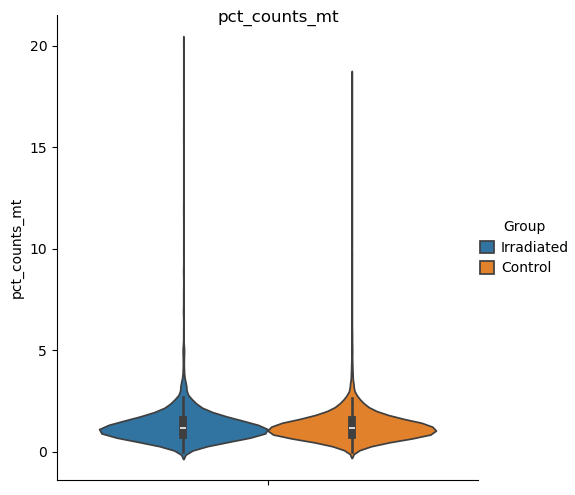

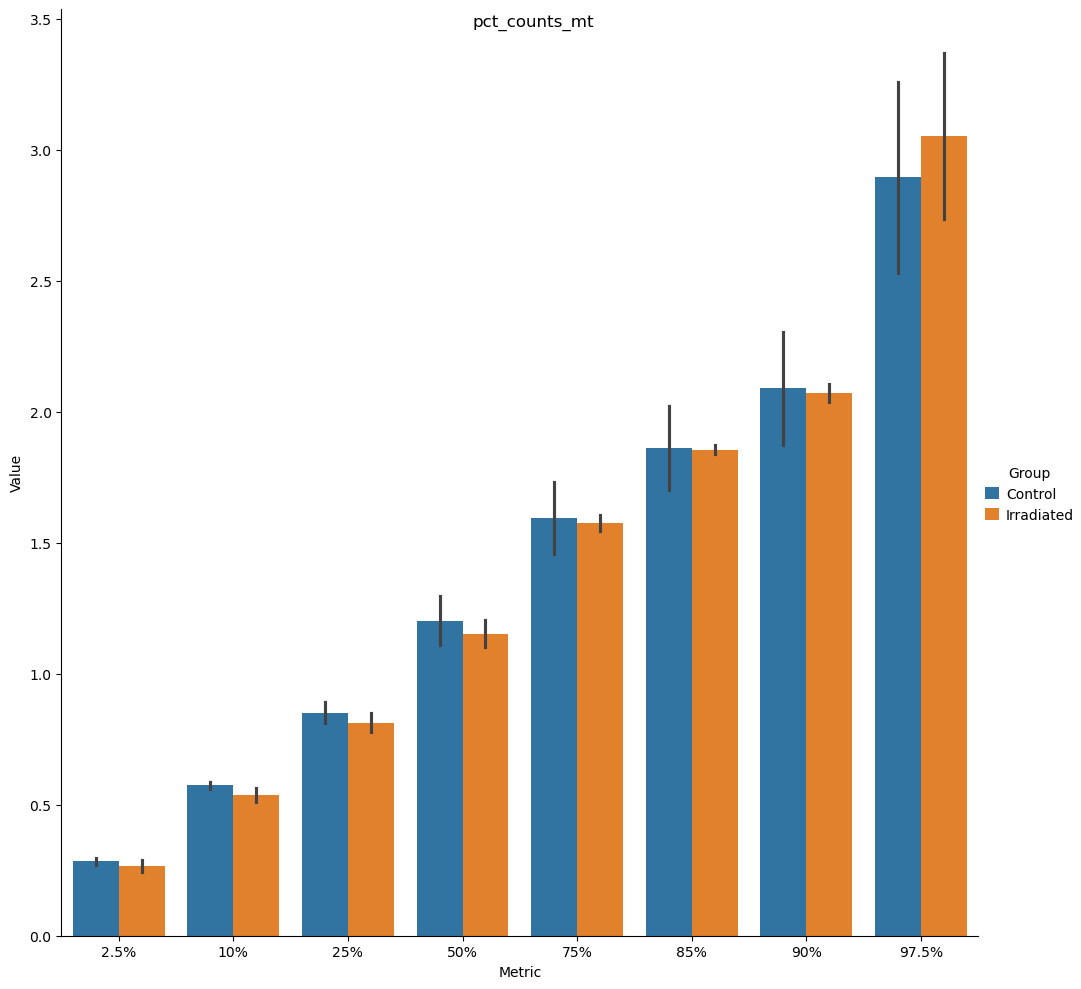

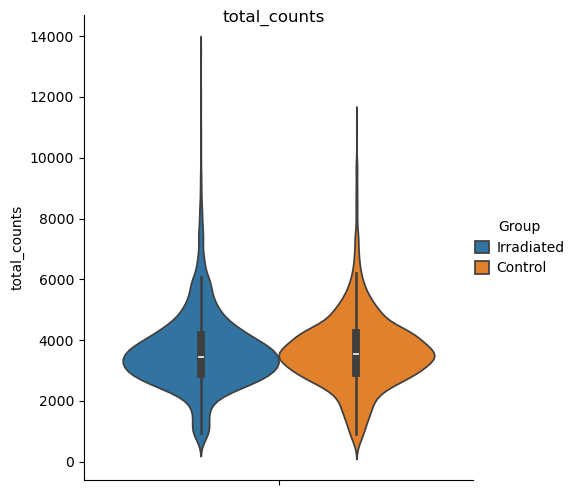

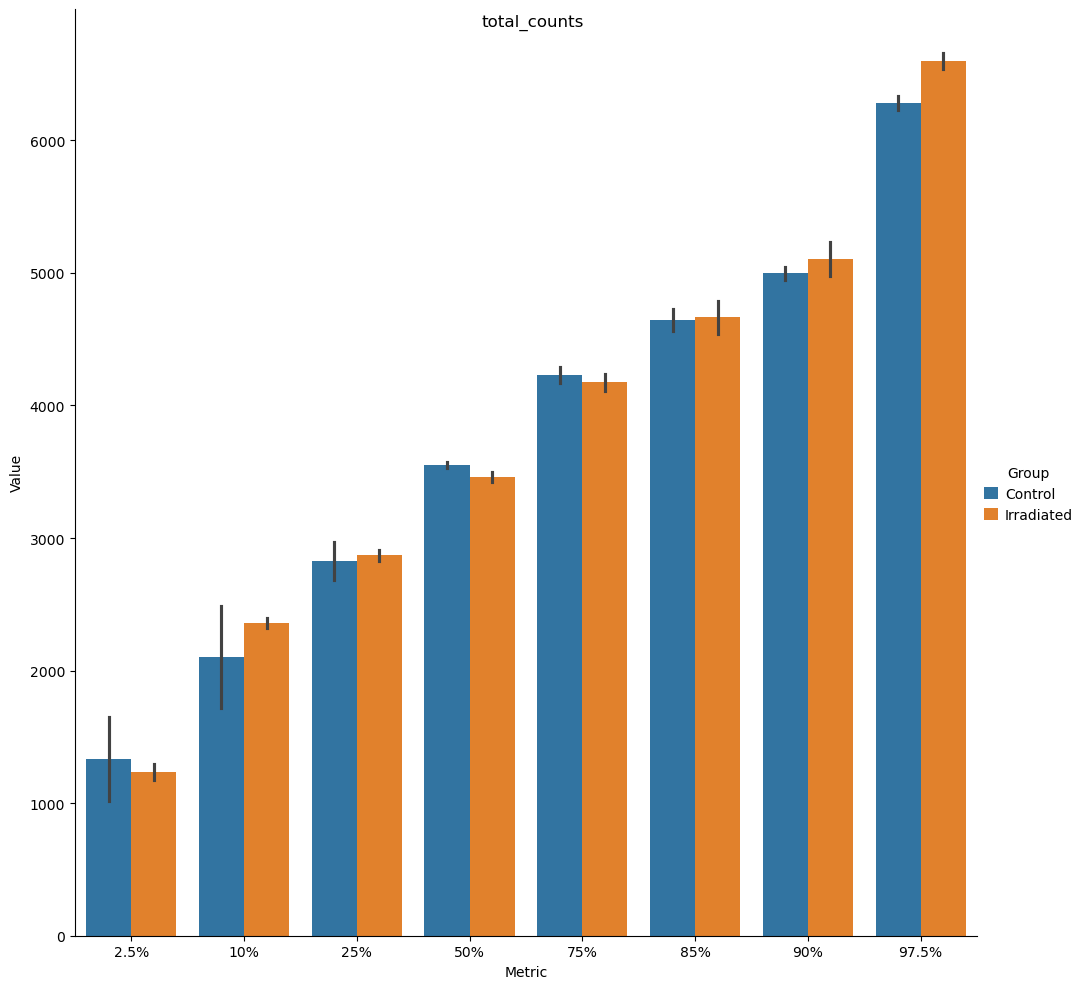

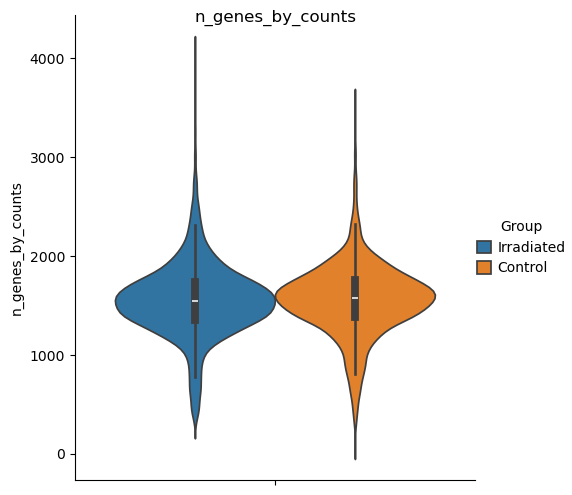

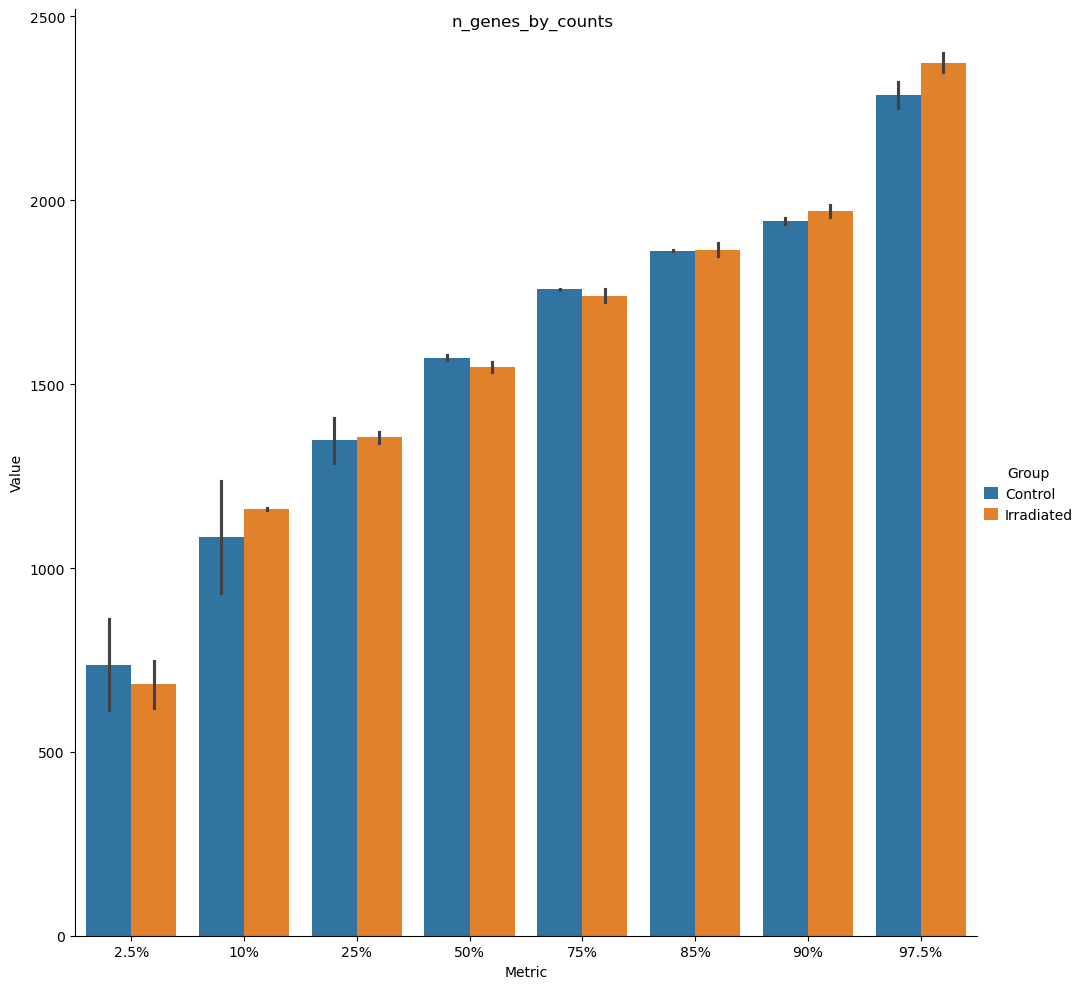

In [5]:
%matplotlib inline

plot_qc = False  # change to True to get sample-level QC plots (a bit slow)
qcs, n_cells_by_counts, descriptives, figs = scflow.pp.perform_qc_multi(
    adatas, col_batch=col_batch, col_sample=col_sample, plot=plot_qc,
    percentiles=[0.025, 0.10, 0.25, 0.50, 0.75, 0.85, 0.90, 0.975],
    figsize=(10, 10))  # perform QC on individual samples
for x in qcs:  # iterate QC metrics % plot percentiles by group
    fig = sns.catplot(qcs, y=x, hue=col_batch, kind="violin")
    fig.fig.suptitle(x)
    fig = sns.catplot(descriptives.loc[:, :, x][[
        i for i in descriptives if ("%" in i)]].stack().to_frame("Value"),
                      x="Metric", y="Value", kind="bar",
                      hue=col_batch, height=10)
    fig.fig.suptitle(x)
descriptives.stack().unstack("Variable").round()

## Auto-Detect Filtering Thresholds

Use 2.5th and/& 97.5th percentile (sample-specific) as minimum genes per cell and minimum and maximum total counts (subject to specified absolute minima). Use 97.5th percentile as upper bound for percent mitochondrial count. 

Use an absolute minimum cells per gene.

Also include arguments to run a PCA on individual samples before integrating.

In [6]:
# Options
bounds = descriptives[["2.5%", "97.5%"]].apply(lambda x: list(
    x), axis=1).unstack("Variable")  # list top/bottom 5% (~sample, variable)
abs_min_cells = 10  # regardless of %ile, minimum cells to retain gene
abs_min_genes = 200  # regardless of %ile, minimum genes to retain cell
abs_min_count = 300  # regardless of %ile, minimum counts to retain cell
abs_max_mt = 5  # regardless of %ile, absolute maximum mitochonrial content
n_top_genes = 2000  # number of top genes to count as HVGs

# Set Thresholds
kws_pp = {}
for x in adatas:
    b_x = bounds.loc[x]
    b_counts =  b_x["total_counts"] if isinstance(b_x[
            "total_counts"], list) else b_x["total_counts"].iloc[0]
    b_counts = [max(b_counts[0], abs_min_count), b_counts[1]]
    kws_pp[x] = {
        "min_max_genes": [max((b_x["n_genes_by_counts"] if isinstance(
            b_x["n_genes_by_counts"], list) else b_x[
                "n_genes_by_counts"].iloc[0])[0], abs_min_genes), None],
        "min_max_cells": [abs_min_cells, None],
        # "min_max_cells": [max((b_x["n_cells_by_counts"] if isinstance(
        #     b_x["n_genes_by_counts"], list) else b_x[
        #         "n_genes_by_counts"].iloc[0])[0], abs_min_cells), None],
        # "max_mt": min(abs_max_mt, (b_x["pct_counts_mt"] if isinstance(b_x[
        #     "pct_counts_mt"], list) else b_x["pct_counts_mt"].iloc[0])[1]),
        "max_mt": abs_max_mt,
        "min_max_counts": b_counts,
        # "vars_regress_out": ["total_counts"],
        "target_sum": 1e4,
        "zero_center": True, "max_value": 10,  # scaling
        "n_top_genes": n_top_genes,
        "doublet_detection": "drop"
    }
print("\n".join([f"{s}: {kws_pp[s]}" for s in kws_pp]))
pd.DataFrame(kws_pp).T

GSM4494887: {'min_max_genes': [747.6, None], 'min_max_cells': [10, None], 'max_mt': 5, 'min_max_counts': [1297.0, 6541.150000000006], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
GSM4494884: {'min_max_genes': [861.0, None], 'min_max_cells': [10, None], 'max_mt': 5, 'min_max_counts': [1647.075, 6337.575000000001], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
GSM4494886: {'min_max_genes': [613.7500000000001, None], 'min_max_cells': [10, None], 'max_mt': 5, 'min_max_counts': [1016.85, 6229.450000000001], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
GSM4494885: {'min_max_genes': [619.1, None], 'min_max_cells': [10, None], 'max_mt': 5, 'min_max_counts': [1172.0, 6657.750000000001], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}


,min_max_genes,min_max_cells,max_mt,min_max_counts,target_sum,zero_center,max_value,n_top_genes,doublet_detection
GSM4494887,"[747.6, None]","[10, None]",5,"[1297.0, 6541.150000000006]",10000.0,True,10,2000,drop
GSM4494884,"[861.0, None]","[10, None]",5,"[1647.075, 6337.575000000001]",10000.0,True,10,2000,drop
GSM4494886,"[613.7500000000001, None]","[10, None]",5,"[1016.85, 6229.450000000001]",10000.0,True,10,2000,drop
GSM4494885,"[619.1, None]","[10, None]",5,"[1172.0, 6657.750000000001]",10000.0,True,10,2000,drop


# Integrate

## In-Memory Approach

See the "On-Disk Approach" for a more sophisticated approach to defining `kws_integrate` (more options).

In [7]:
# %%time

# # Integrate
# join_method = "outer"  # or "inner"
# kws_integrate = {"kws_pp": kws_pp, "n_top_genes": 10000,
#                  "fill_value": np.nan,
#                  "col_batch": None,  # suppress using batch as covariate
#                  "join": join_method, "merge": "unique", "use_rapids": True}
# self = scflow.Rna(adatas, col_sample=col_sample, col_batch=col_batch,
#                   kws_integrate=kws_integrate)
# self.rna.obs = self.rna.obs.assign(kws_integrate=str(kws_integrate))

# # Write Files for Processed/Integrated Objects?
# if overwrite is True or not os.path.exists(file_new):
#     os.makedirs("data", exist_ok=True)
#     self.rna.write_h5ad(file_new)
# for x in adatas:
#     pfp = os.path.join("data", f"{x}_processed.h5ad")
#     if overwrite is True or not os.path.exists(pfp):
#         adatas[x].write_h5ad(pfp)
# del adatas  # to save memory; now integrated in `self.rna`

# # Display
# print(self.rna)
# # print(self.rna.var.head())
# self.rna.obs

## On-Disk Approach

### Preprocess Individual

#### Filter & Normalize

In [ ]:
# Preprocess
if overwrite is False:
    raise ValueError("Must be able to overwrite to use on-disk option")
files_individual = dict(zip(files.keys(), [os.path.join(
    "data", f"{x}_processed.h5ad") for x in files]))  # new individual files
var_names = []  # to store genes not filtered out for each sample
for x in files:  # iterate sample files
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}")
    adatas[x].obs.loc[:, f"kws_pp_{col_sample}"] = str(kws_pp[x])  # store kws
    adatas[x] = scflow.pp.preprocess(adatas[x], **kws_pp[x], plot_qc=False)
    var_names += [set(adatas[x].var_names)]  # track what genes still present

# Decide Join Method
shared_genes = set.intersection(*var_names)  # genes in all after filtering
all_genes = set.union(*var_names)  # genes in any post-filter sample
print(f"{len(shared_genes)} genes present in all samples post-filtering (out"
      f" of {len(all_genes)} total genes present in any post-filter sample)")
join_method = "inner" if len(shared_genes) / len(all_genes) >= 0.5 else \
    "outer"  # outer join if <1/2 of genes shared across all samples

# Number of Cells
n_cells = pd.DataFrame({x: pd.Series({
    "n_cells_original": adatas[x].obs["n_cells_original_sample"].iloc[0],
    "n_cells": adatas[x].obs.shape[0]}) for x in adatas}).T
n_cells = n_cells.assign(percent_cells_retained=100 * round(n_cells[
    "n_cells"] / n_cells["n_cells_original"], 2))
print(f"\n\n\n{'=' * 80}\n# Cells Post-Processing\n{'=' * 80}\n\n")
n_cells



GSM4494887
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 2170 × 27998
    obs: 'Group', 'sample', 'Source Name', 'Treatment', 'Unnamed: 3', 'Run', 'age', 'Assay Type', 'AssemblyName', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'cell_type', 'Center Name', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'GEO_Accession (exp)', 'Instrument', 'intentional_duplicate (run)', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'source_name', 'SRA Study', 'strain', 'n_cells_original_sample', 'kws_pp_sample', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'log1p_total_counts_hb'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'total_co

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


Automatically set threshold at doublet score = 0.35
Detected doublet rate = 0.7%
Estimated detectable doublet fraction = 1.7%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 42.9%
	***Normalizing...
	***Detecting highly variable genes...
	***Scaling data...


GSM4494884
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 2670 × 27998
    obs: 'Group', 'sample', 'Source Name', 'Treatment', 'Unnamed: 3', 'Run', 'age', 'Assay Type', 'AssemblyName', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'cell_type', 'Center Name', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'GEO_Accession (exp)', 'Instrument', 'intentional_duplicate (run)', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'source_name', 'SRA Study', 'strain', 'n_cells_original_sample', 'kws_pp_sample', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_cou

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


	***Normalizing...
	***Detecting highly variable genes...
	***Scaling data...


GSM4494886
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 1623 × 27998
    obs: 'Group', 'sample', 'Source Name', 'Treatment', 'Unnamed: 3', 'Run', 'age', 'Assay Type', 'AssemblyName', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'cell_type', 'Center Name', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'GEO_Accession (exp)', 'Instrument', 'intentional_duplicate (run)', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'source_name', 'SRA Study', 'strain', 'n_cells_original_sample', 'kws_pp_sample', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'log1p_total_coun

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


Automatically set threshold at doublet score = 0.31
Detected doublet rate = 1.5%
Estimated detectable doublet fraction = 3.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 47.9%
	***Normalizing...
	***Detecting highly variable genes...
	***Scaling data...


GSM4494885
	***Activating layer 'counts'...
AnnData object with n_obs × n_vars = 2023 × 27998
    obs: 'Group', 'sample', 'Source Name', 'Treatment', 'Unnamed: 3', 'Run', 'age', 'Assay Type', 'AssemblyName', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'cell_type', 'Center Name', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'GEO_Accession (exp)', 'Instrument', 'intentional_duplicate (run)', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'source_name', 'SRA Study', 'strain', 'n_cells_original_sample', 'kws_pp_sample', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_cou

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/cuml/internals/api_decorators.py:216: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ret = func(*args, **kwargs)


,n_cells_original,n_cells,percent_cells_retained
GSM4494887,2170,2042,94.0
GSM4494884,2670,2509,94.0
GSM4494886,1623,1513,93.0
GSM4494885,2023,1897,94.0


#### Test Preprocessing

Unit tests

In [9]:
for p, ann in zip([kws_pp[x] for x in kws_pp], [adatas[x] for x in adatas]):
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n")
    if join_method == "inner":
        assert all(ann.var["n_cells_by_counts"] >= p["min_max_cells"][0])
        assert all(ann.var["n_cells_by_counts"] <= p[
            x]["min_max_cells"][1]) if kws_pp[x]["min_max_cells"][1] else True
    assert all(ann.obs["n_genes_by_counts"] >= p["min_max_genes"][0])
    assert all(ann.obs["n_genes_by_counts"] <= p[
        "min_max_genes"][1]) if p["min_max_genes"][1] else True
    assert all(ann.obs["pct_counts_mt"] <= p["max_mt"])
    assert all(ann.obs["total_counts"] >= p["min_max_counts"][0])
    assert all(ann.obs["total_counts"] <= p["min_max_counts"][1]) if (
        p["min_max_counts"][1]) else True
    print(p)
    print(ann.obs[["n_genes", "pct_counts_mt", "total_counts"]
                  ].describe().loc[["min", "max"]])
    print(ann.var[["n_cells_by_counts"]].describe().loc[[
        "min", "max"]])



GSM4494885

{'min_max_genes': [747.6, None], 'min_max_cells': [10, None], 'max_mt': 5, 'min_max_counts': [1297.0, 6541.150000000006], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
     n_genes  pct_counts_mt  total_counts
min    760.0        0.00000        1297.0
max   2809.0        4.86805        6490.0
     n_cells_by_counts
min               10.0
max             2169.0


GSM4494885

{'min_max_genes': [861.0, None], 'min_max_cells': [10, None], 'max_mt': 5, 'min_max_counts': [1647.075, 6337.575000000001], 'target_sum': 10000.0, 'zero_center': True, 'max_value': 10, 'n_top_genes': 2000, 'doublet_detection': 'drop'}
     n_genes  pct_counts_mt  total_counts
min    861.0       0.000000        1654.0
max   2574.0       4.409603        6334.0
     n_cells_by_counts
min               10.0
max             2669.0


GSM4494885

{'min_max_genes': [613.7500000000001, None], 'min_max_cells': [10, None], 'max_mt': 5, 'min_max_coun

### Cluster Individual

#### *A Priori* Clustering Parameters

In [10]:
# %%time

# # Clustering Parameter Options (Only Applied If `kws_cluster` != None)
# resolution_individual, min_dist_individual = 0.15, 1.5
# col_cluster_individual = "annotation_by_markers_individual"
# unlabeled_cat = "Heterogeneous"  # if can't find one best-fit cell label
# cci_scanvi = col_cluster_individual + "_heterogeneous_collapsed"
# sep = " | "  # separator for heterogeneous annotations

# # Preprocessing & (Optionally) Clustering
# if overwrite is False and os.path.exists(pfp):
#     raise ValueError("Must be able to overwrite to use on-disk option")
# # del adatas
# for x in files:  # iterate sample files
#     if kws_cluster is not None:  # cluster individual sample?
#         kws_cl = {"resolution": resolution_individual[x],
#                   "min_dist": min_dist_individual[x], **kws_cluster}
#         self.rna.obs.loc[:, "kws_cluster_individual"] = str(kws_cl)
#         adatas[x] = scflow.pp.cluster(
#             adatas[x], resolution=resolution_individual,
#             min_dist=min_dist_individual, plot=False,
#             col_celltype="leiden_individual", **kws_cl)  # cluster
#         sc.tl.rank_genes_groups(
#             adatas[x], "leiden_individual", n_genes=None, rankby_abs=False,
#             key_added="rank_genes_groups_leiden_individual",
#             copy=False)  # find markers/DEGs
#         if markers_predefined is not None:  # markers specified?
#             _, adatas[x] = scflow.pp.annotate_by_marker_overlap(
#                 adatas[x], markers_predefined,
#                 col_celltype="leiden_individual",
#                 col_celltype_new=col_cluster_individual, sep=sep,
#                 celltypes_superhierarchical=cts_superhierarchical,
#                 # top_n_markers=20,
#                 adj_pval_threshold=1e-10,
#                 method="overlap_coef", inplace=True)  # annotate by markers
#             if rename_marker_based_annotation is not None:
#                 adatas[x].obs.loc[:, col_cluster_individual] = adatas[
#                     x].obs[col_cluster_individual].replace(
#                         rename_marker_based_annotation)  # re-name
#             adatas[x].obs.loc[:, cci_scanvi] = adatas[x].obs[
#                 col_cluster_individual].apply(lambda x: unlabeled_cat if (
#                     sep in x) else x)  # re-label heterogeneous annotations
#     var_names += [set(adatas[x].var_names)]  # track what genes still there

# # Write Objects
# for x in adatas:
#     print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n\n{adatas[x]}\n")
#     adatas[x].write_h5ad(files_individual[x])  # write individual file

# # Plot
# if kws_cluster is not None:
#     for x in files:  # iterate sample files
#         ccs = [v for v in ["leiden_individual", col_cluster_individual
#                            ] if v in adatas[x].obs]  # columns for UMAP
#         print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}")
#         sc.pl.umap(adatas[x], color=ccs, wspace=0.4)  # plot UMAP
# del adatas  # save memory

#### Optimize Hyperparameters

Iterate different clustering parameters to ensure extraction of common cell types

Make sample-specific alterations to one sample's annotation



GSM4494887
	***Calculating PCA with 50 components...
	***Building neighborhood...
	***Embedding UMAP with minimum distance 0.3...
	***Performing Leiden clustering with resolution 0.5...


2025-12-23 10:52:38 | [INFO] init




GSM4494884
	***Calculating PCA with 50 components...
	***Building neighborhood...
	***Embedding UMAP with minimum distance 0.3...
	***Performing Leiden clustering with resolution 0.5...


GSM4494886
	***Calculating PCA with 50 components...
	***Building neighborhood...
	***Embedding UMAP with minimum distance 0.3...
	***Performing Leiden clustering with resolution 0.5...


GSM4494885
	***Calculating PCA with 50 components...
	***Building neighborhood...
	***Embedding UMAP with minimum distance 0.3...
	***Performing Leiden clustering with resolution 0.5...
No valid clustering found for GSM4494887
No valid clustering found for GSM4494884
No valid clustering found for GSM4494886
No valid clustering found for GSM4494885
No Valid Clustering Scheme Yet: ['GSM4494887', 'GSM4494884', 'GSM4494886', 'GSM4494885']


GSM4494887

AnnData object with n_obs × n_vars = 2042 × 10681
    obs: 'Group', 'sample', 'Source Name', 'Treatment', 'Unnamed: 3', 'Run', 'age', 'Assay Type', 'AssemblyName', 'AvgS

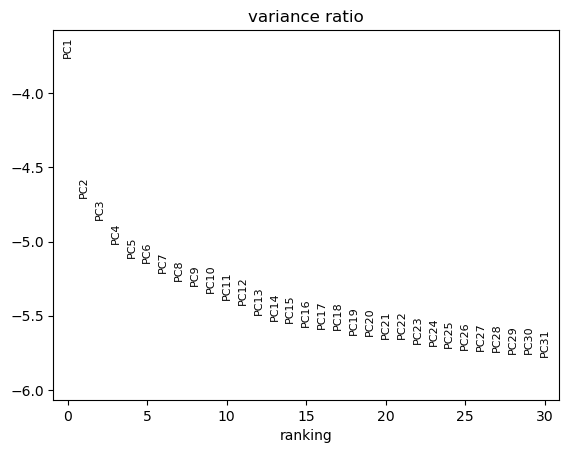

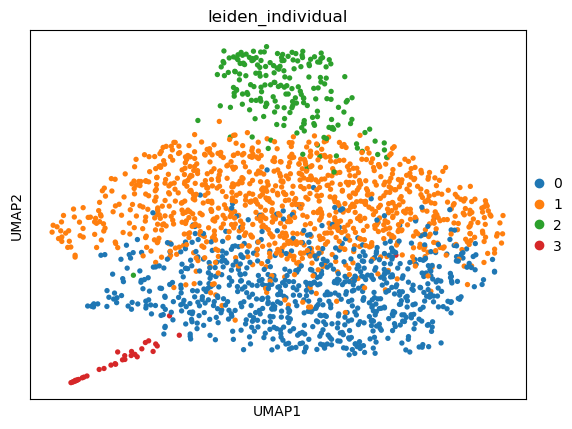

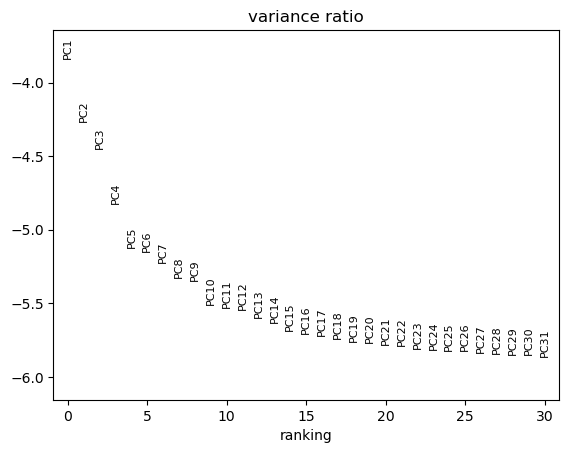

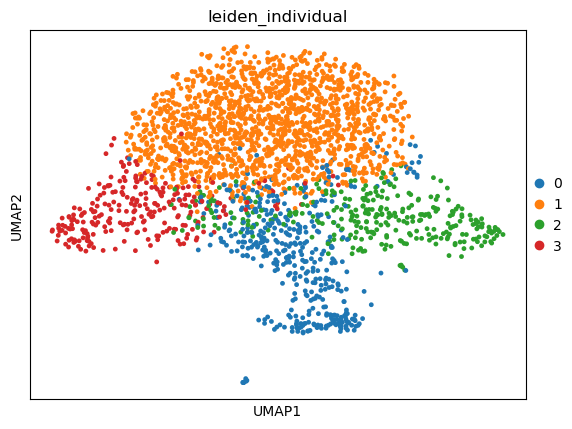

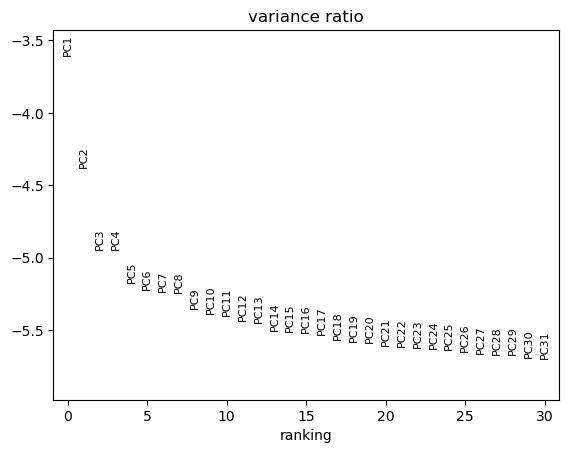

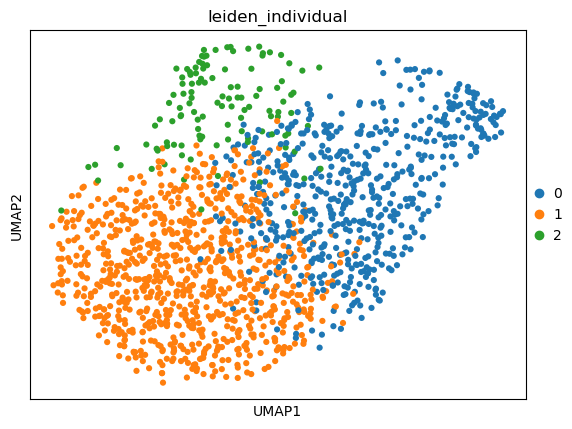

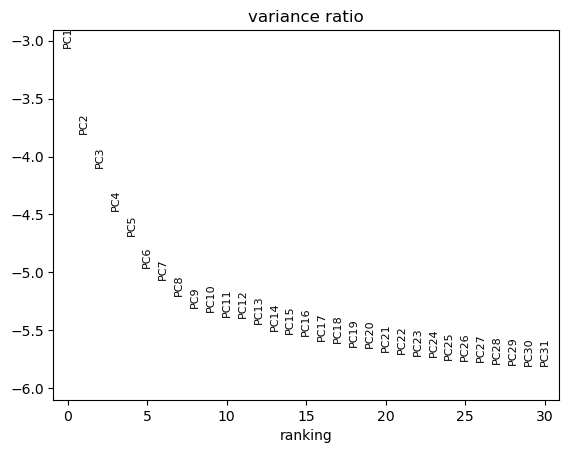

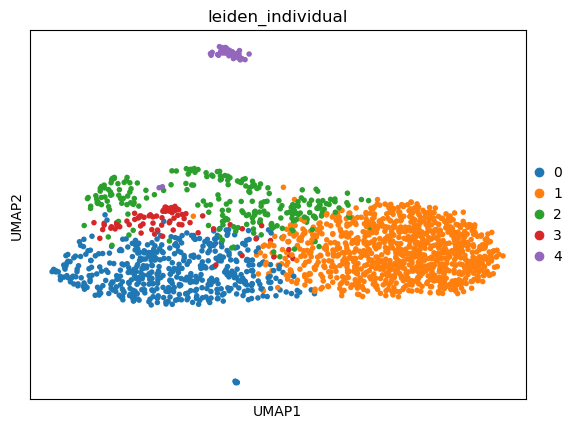

In [ ]:
# Clustering Parameter Options (Only Applied If `kws_cluster` != None)
ondisk = True
annotate = False
# annotate = True
req_cts = None
# req_cts = ["Neuron", "OPC", "Oligodendrocyte", "Astrocyte", "Microglial"]
# prohib_cts = ["Excitatory-Inhibitory"]
prohib_cts = None
resn_list = [0.5]
dist_list = [0.3]
# resn_list = [1, 2, 1.75, 1.2, 0.5, 1.5]
# dist_list = [1.5, 0.75, 0.5, 1, 0.3]
col_cluster_individual = "annotation_by_markers_individual"
unlabeled_cat = "Heterogeneous"  # if can't find one best-fit cell label
cci_scanvi = col_cluster_individual + "_heterogeneous_collapsed"
sep = " | "  # separator for heterogeneous annotations

# Clustering
for x in files:  # iterate sample files
    valid_cts = False
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}")
    for r in resn_list:
        if valid_cts is True:
            break
        for t in dist_list:
            if valid_cts is True:
                break
            c_i = f"leiden_individual_res{r}dist{t}"
            cai = f"{col_cluster_individual}_res{r}dist{t}"
            kws_cl = {"resolution": r, "min_dist": t, **kws_cluster}
            adatas[x] = scflow.pp.cluster(
                adatas[x], plot=False, col_celltype=c_i, **kws_cl)
            sc.tl.rank_genes_groups(
                adatas[x], c_i, n_genes=None,
                key_added=f"rank_genes_groups_{c_i}",
                copy=False)  # find markers/DEGs
            if annotate is False:
                valid_cts = True
                adatas[x].obs.loc[:, "leiden_individual"] = adatas[x].obs[c_i]
                adatas[x].obs.loc[:, "kws_cluster_individual"] = str(kws_cl)
                continue
            _, adatas[x] = scflow.pp.annotate_by_marker_overlap(
                adatas[x], mks_collapsed,
                col_celltype=c_i, col_celltype_new=cai, sep=sep,
                celltypes_superhierarchical=cts_superhierarchical,
                # top_n_markers=20,
                adj_pval_threshold=1e-15,
                method="overlap_count", inplace=True)  # annotate
            if rename_marker_based_annotation is not None:
                adatas[x].obs.loc[:, cai] = adatas[x].obs[cai].replace(
                        rename_marker_based_annotation)  # re-name
            print(list(adatas[x].obs[cai].unique()))
            adatas[x].obs.loc[:, cci_scanvi] = adatas[x].obs[
                cai].apply(lambda x: unlabeled_cat if (sep in x) else x)
            valid_cts = req_cts is None or all([
                q in adatas[x].obs[cai].unique() for q in req_cts])
            valid_cts = valid_cts and (prohib_cts is None or all([
                q not in adatas[x].obs[cai].unique() for q in prohib_cts]))
            valid_cts = False if any(adatas[x].obs[
                cci_scanvi] == unlabeled_cat) else valid_cts
            if valid_cts is True:
                adatas[x].obs.loc[:, "leiden_individual"] = adatas[x].obs[c_i]
                adatas[x].obs.loc[:, col_cluster_individual] = adatas[
                    x].obs[cai]
                adatas[x].obs.loc[:, "kws_cluster_individual"] = str(kws_cl)
                print(kws_cl)

# Detect Samples with No Valid Clustering Scheme
no_valid = []
for x in files:
    if all((i in adatas[x].obs for i in [
            "leiden_individual", col_cluster_individual])) is False:
        print(f"No valid clustering found for {x}")
        no_valid += [x]
print(f"No Valid Clustering Scheme Yet: {no_valid}")

# # Individual Tweak
# samp = "RRRM2_BRN_GC_ISS-T_YNG_GY4"
# cols_tries = [i for i in adatas[samp].obs if "leiden_" in i]
# cts_try = cols_tries[14]
# _, adatas[samp] = scflow.pp.annotate_by_marker_overlap(
#     adatas[samp], mks_collapsed, col_celltype=cts_try,
#     col_celltype_new=col_cluster_individual + "_new", sep=sep,
#     adj_pval_threshold=1e-5,
#     method="overlap_coef", inplace=True)  # annotate by markers
# adatas[samp].obs.loc[:, "leiden_individual"] = adatas[samp].obs[cts_try]
# adatas[samp].obs.loc[:, col_cluster_individual] = adatas[samp].obs[
#     col_cluster_individual + "_new"]
# adatas[samp].obs["kws_cluster_individual"] = str({"resolution": float(
#     cts_try.split("res")[1].split("dist")[0]), "min_dist": float(
#         cts_try.split("res")[1].split("dist")[1])})

# Write Objects
for x in adatas:
    print(f"\n\n{'=' * 80}\n{x}\n{'=' * 80}\n\n{adatas[x]}\n")
    if "tocsr" in dir(adatas[x].X):
        adatas[x].X = adatas[x].X.tocsr()
    adatas[x].write_h5ad(files_individual[x])  # write individual file

# Print Parameters Used
for x in adatas:
    print(adatas[x].obs["kws_cluster_individual"])

# Plot
for x in adatas:
    sc.pl.pca_variance_ratio(adatas[x], log=True)
    sc.pl.umap(adatas[x], color=[i for i in [
        "leiden_individual", col_cluster_individual] if i in adatas[x].obs],
               wspace=0.4)
if ondisk is False:
    del adatas

### Concatenate & Integrate

If you are concerned about hard drive space, you may want to delete `file_concat` and `files_individual` after running this cell.


>>>Concatenating data...

>>>Re-Normalizing & Finding HVGs for Overall Data...


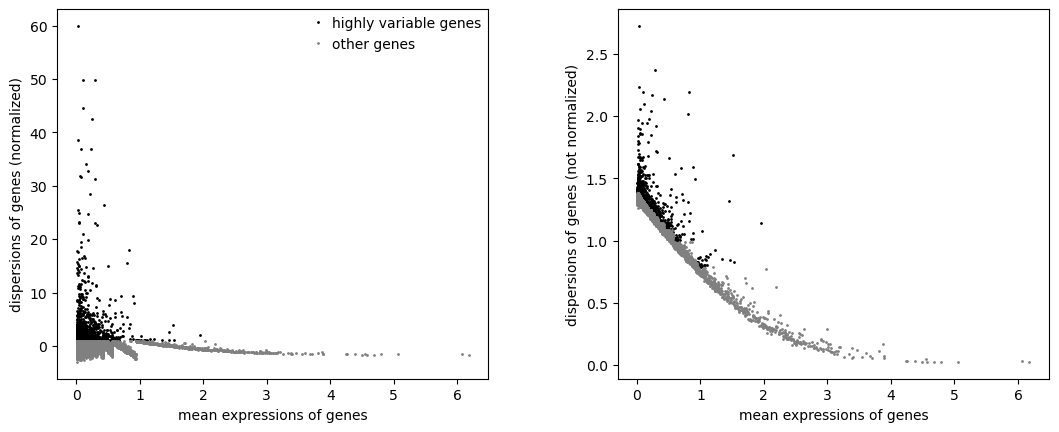


>>>Subsetting to top 2000 HVGs...

>>>Integrating with respect to sample (HARMONY)...
	***Using log1p layer for Harmony...


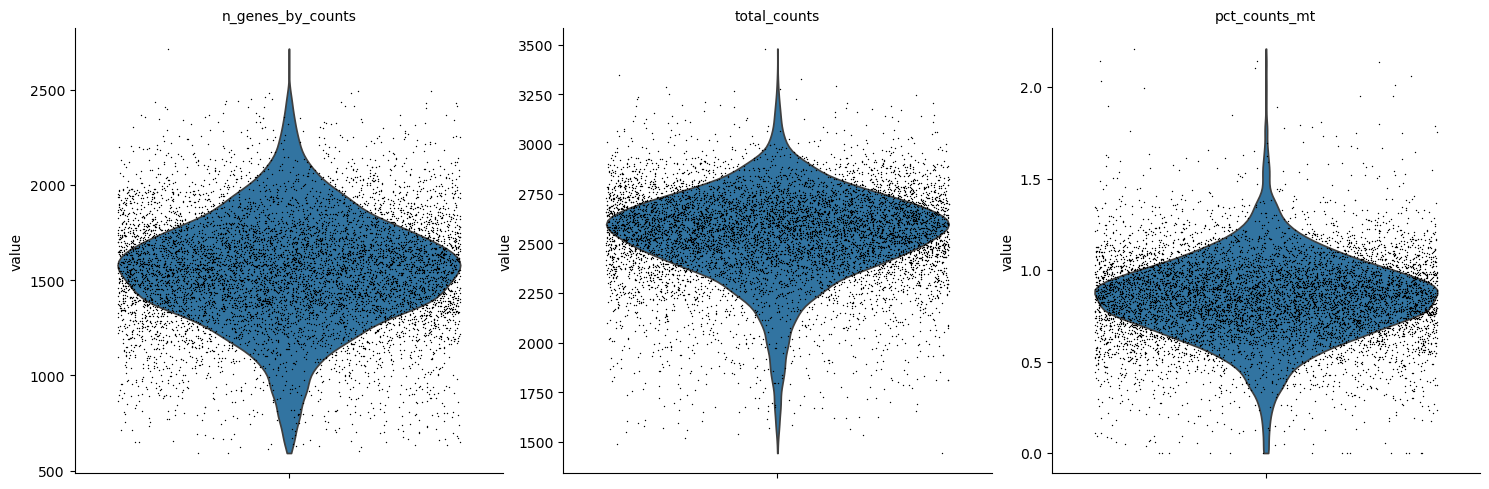

count    10094.000000
mean      1217.452249
std       1516.481814
min         41.000000
25%        265.000000
50%        652.500000
75%       1491.000000
max       7961.000000
Name: n_cells_by_counts, dtype: float64


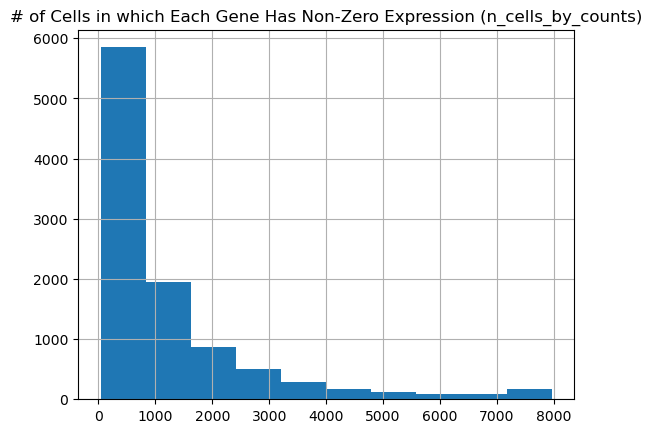

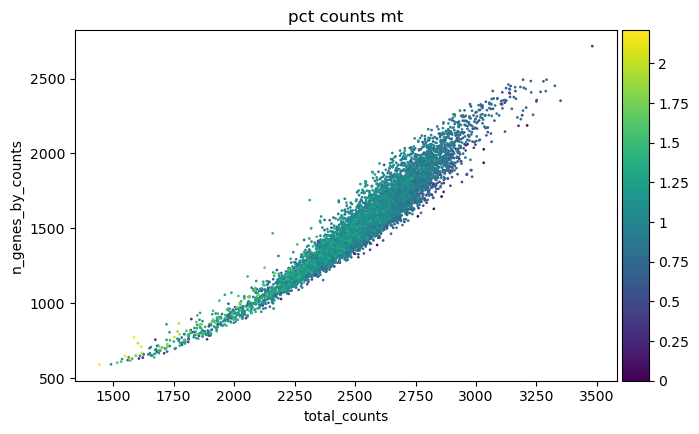

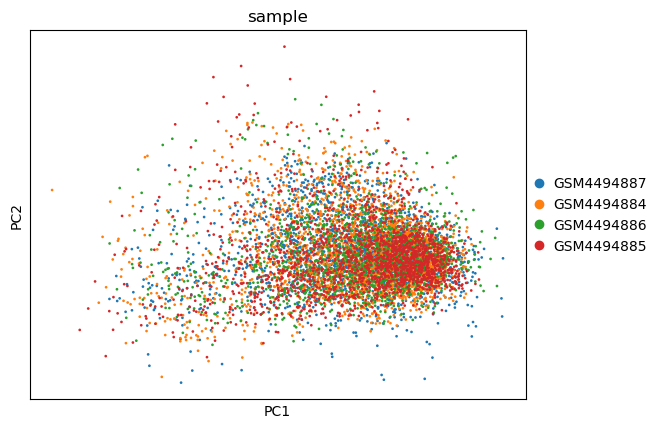

AnnData object with n_obs × n_vars = 7961 × 10094
    obs: 'Group', 'sample', 'Source Name', 'Treatment', 'Unnamed: 3', 'Run', 'age', 'Assay Type', 'AssemblyName', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'cell_type', 'Center Name', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'GEO_Accession (exp)', 'Instrument', 'intentional_duplicate (run)', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'source_name', 'SRA Study', 'strain', 'n_cells_original_sample', 'kws_pp_sample', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'log1p_total_counts_hb', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_individual_res0.5dist0.3', 'leiden_individual',

,Group,sample,Source Name,Treatment,Unnamed: 3,Run,age,Assay Type,AssemblyName,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Consent,DATASTORE filetype,DATASTORE provider,DATASTORE region,Experiment,GEO_Accession (exp),Instrument,intentional_duplicate (run),LibraryLayout,LibrarySelection,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,source_name,SRA Study,strain,n_cells_original_sample,kws_pp_sample,n_genes_by_counts,total_counts,log1p_n_genes_by_counts,log1p_total_counts,total_counts_mt,pct_counts_mt,log1p_total_counts_mt,total_counts_ribo,pct_counts_ribo,log1p_total_counts_ribo,total_counts_hb,pct_counts_hb,log1p_total_counts_hb,n_counts,n_genes,doublet_score,predicted_doublet,leiden_individual_res0.5dist0.3,leiden_individual,kws_cluster_individual,kws_integrate
AAACCTGAGAGCCTAG-1_GSM4494887,Irradiated,GSM4494887,GSM4494887,Irradiated,One Week,SRR11601146,P21,RNA-Seq,MM10,98,9915658522,PRJNA627726,SAMN14681471,3873440261,microglia cells in brain,GEO,public,"run.zq,TenX,sra","s3,ncbi,gs","ncbi.public,s3.us-east-1,gs.us-east1",SRX8167773,GSM4494887,Illumina HiSeq 2500,NaN,PAIRED,cDNA,TRANSCRIPTOMIC,Mus musculus,ILLUMINA,2020-06-01T00:00:00Z,2020-04-23T18:29:00Z,1,Microglia cells in brain,SRP258170,C57BL/6,2170,"{'min_max_genes': [747.6, None], 'min_max_cell...",1531,2575.520996,7.334329,7.854195,17.726765,0.688279,2.929954,146.253937,5.678616,4.992158,0.0,0.0,0.0,3200.0,1536,0.114563,False,1,1,"{'resolution': 0.5, 'min_dist': 0.3, 'n_comps'...","{'col_celltype': None, 'flavor': 'harmony', 'k..."
AAACCTGAGTGTCCAT-1_GSM4494887,Irradiated,GSM4494887,GSM4494887,Irradiated,One Week,SRR11601146,P21,RNA-Seq,MM10,98,9915658522,PRJNA627726,SAMN14681471,3873440261,microglia cells in brain,GEO,public,"run.zq,TenX,sra","s3,ncbi,gs","ncbi.public,s3.us-east-1,gs.us-east1",SRX8167773,GSM4494887,Illumina HiSeq 2500,NaN,PAIRED,cDNA,TRANSCRIPTOMIC,Mus musculus,ILLUMINA,2020-06-01T00:00:00Z,2020-04-23T18:29:00Z,1,Microglia cells in brain,SRP258170,C57BL/6,2170,"{'min_max_genes': [747.6, None], 'min_max_cell...",1266,2387.633057,7.144407,7.778477,23.825291,0.997862,3.211863,171.614777,7.187653,5.151062,0.0,0.0,0.0,2535.0,1272,0.096774,False,1,1,"{'resolution': 0.5, 'min_dist': 0.3, 'n_comps'...","{'col_celltype': None, 'flavor': 'harmony', 'k..."
AAACCTGCAACGATGG-1_GSM4494887,Irradiated,GSM4494887,GSM4494887,Irradiated,One Week,SRR11601146,P21,RNA-Seq,MM10,98,9915658522,PRJNA627726,SAMN14681471,3873440261,microglia cells in brain,GEO,public,"run.zq,TenX,sra","s3,ncbi,gs","ncbi.public,s3.us-east-1,gs.us-east1",SRX8167773,GSM4494887,Illumina HiSeq 2500,NaN,PAIRED,cDNA,TRANSCRIPTOMIC,Mus musculus,ILLUMINA,2020-06-01T00:00:00Z,2020-04-23T18:29:00Z,1,Microglia cells in brain,SRP258170,C57BL/6,2170,"{'min_max_genes': [747.6, None], 'min_max_cell...",1729,2699.440918,7.455877,7.901170,20.242357,0.749872,3.055997,210.009705,7.779748,5.351904,0.0,0.0,0.0,4141.0,1738,0.171662,False,0,0,"{'resolution': 0.5, 'min_dist': 0.3, 'n_comps'...","{'col_celltype': None, 'flavor': 'harmony', 'k..."
AAACCTGGTCCTGCTT-1_GSM4494887,Irradiated,GSM4494887,GSM4494887,Irradiated,One Week,SRR11601146,P21,RNA-Seq,MM10,98,9915658522,PRJNA627726,SAMN14681471,3873440261,microglia cells in brain,GEO,public,"run.zq,TenX,sra","s3,ncbi,gs","ncbi.public,s3.us-east-1,gs.us-east1",SRX8167773,GSM4494887,Illumina HiSeq 2500,NaN,PAIRED,cDNA,TRANSCRIPTOMIC,Mus musculus,ILLUMINA,2020-06-01T00:00:00Z,2020-04-23T18:29:00Z,1,Microglia cells in brain,SRP258170,C57BL/6,2170,"{'min_max_genes': [747.6, None], 'min_max_cell...",1541,2500.953857,7.340836,7.824827,30.675064,1.226535,3.455530,200.487152,8.016428,5.305726,0.0,0.0,0.0,3831.0,1550,0.105072,False,1,1,"{'resolution': 0.5, 'min_dist': 0.3, 'n_comps'...","{'col_celltype': None, 'flavor': 'harmony', 'k..."
AAACCTGTCCAGTATG-1_GSM4494887,Irradiated,GSM4494887,GSM4494887,Irradiated,One Week,SRR11601146,P21,RNA-Seq,MM10,98,9915658522,PRJNA627726,SAMN14681471,3873440261,microglia cells in brain,GEO,public,"run.z

In [12]:
%%time

# Integration Options
cct_available = kws_cluster is not None and (
    markers_predefined is not None) and (
        annotate is True)  # individual annotations available?
kws_vi = {"early_stopping": True,
          "batch_size": 1024,  # raise/lower if more/less than 16 GB VRAM
          "max_epochs": 100,
          "accelerator": "gpu",
          "categorical_covariate_keys": covariates_categorical,
          "continuous_covariate_keys": covariates_continuous,
          "n_latent": 40, "n_hidden": 400}  # scVI/scANVI arguments
if covariates_categorical is not None:
    print(metadata[0][covariates_categorical + [
        col_group]].value_counts().unstack(col_group).replace(
            np.nan, 0).astype(int))
flavor = "harmony"
# flavor = "scanvi"
# flavor = "scvi"
# flavor = "scanorama"
kws_integrate = {
    "col_celltype": cci_scanvi if cct_available else None,
    "flavor": flavor,
    "kws_pp": None, "kws_cluster": None,
    "vars_regress_out": vars_regress_out,
    "max_value": 10, "zero_center": True, "target_sum": 1e4,
    "n_top_genes": n_top_genes,
    "join": join_method, "merge": "same",
    "col_batch": None,  # suppress using batch as covariate
    "drop_non_hvgs": True,  # just for the integration part
    "use_rapids": True,
    "fill_value": np.nan if join_method == "outer" else None,
    "out_file": file_concat, **dict(kws_vi if flavor != "harmony" else {})
}

# If scVI/scANVI Integration & Individual Annotations Available
if kws_integrate["flavor"] in ["scvi", "scanvi"] and cct_available is True:
    kws_integrate.update({"unlabeled_category": unlabeled_cat})

# Integrate & Store Integration Parameters in Object
self = scflow.Rna(files_individual if adatas is None else adatas,
                  col_sample=col_sample, col_batch=col_batch,
                  kws_integrate=kws_integrate)
self.rna.obs = self.rna.obs.assign(kws_integrate=str(kws_integrate))

# Write Files for Processed/Integrated Objects?
if overwrite is True or not os.path.exists(file_new):
    self.rna.write_h5ad(file_new)

# Display
print(self.rna)
self.rna.obs

## Benchmark Integration

In [13]:
# if kws_integrate["flavor"] == "scanvi":
#     try:
#         results_integration_benchmark = scflow.pp.benchmark_integration(
#             self.rna, col_sample, col_celltype="annotation_scanvi")
#     except Exception as err:
#         print(err)

# Clustering

Perform PCA, UMAP embedding, and Leiden clustering on the integrated object

Marker gene-related code looks at top markers by log2fold-change and adjusted p-value cutoffs and sorts by adjusted p-values. Plots for predefined marker expression by cluster (if available) and cluster DEGs are created. Use `kind = ["heat", "dot"]` to get dot plots too.

	***Building neighborhood with 15 neighbors...
	***Embedding UMAP with minimum distance 0.3...
	***Performing Leiden clustering with resolution 0.4...
        n_cells
leiden         
1          4813
0          2678
2           300
3           165
4             5
leiden  sample    
1       GSM4494887    1221
        GSM4494884    1574
        GSM4494886     876
        GSM4494885    1142
0       GSM4494887     708
        GSM4494884     797
        GSM4494886     545
        GSM4494885     628
2       GSM4494887      73
        GSM4494884      95
        GSM4494886      60
        GSM4494885      72
3       GSM4494887      40
        GSM4494884      38
        GSM4494886      32
        GSM4494885      55
4       GSM4494887       0
        GSM4494884       5
        GSM4494886       0
        GSM4494885       0
dtype: int64


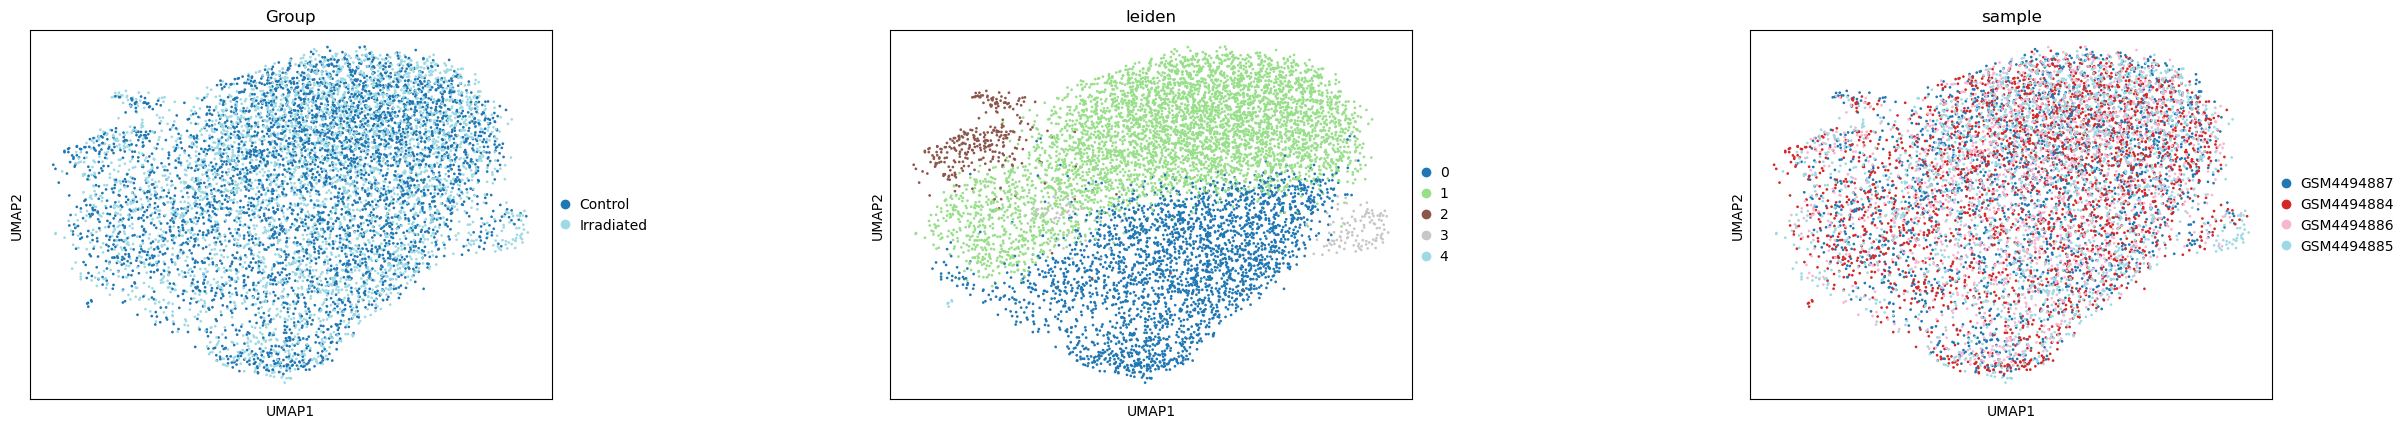

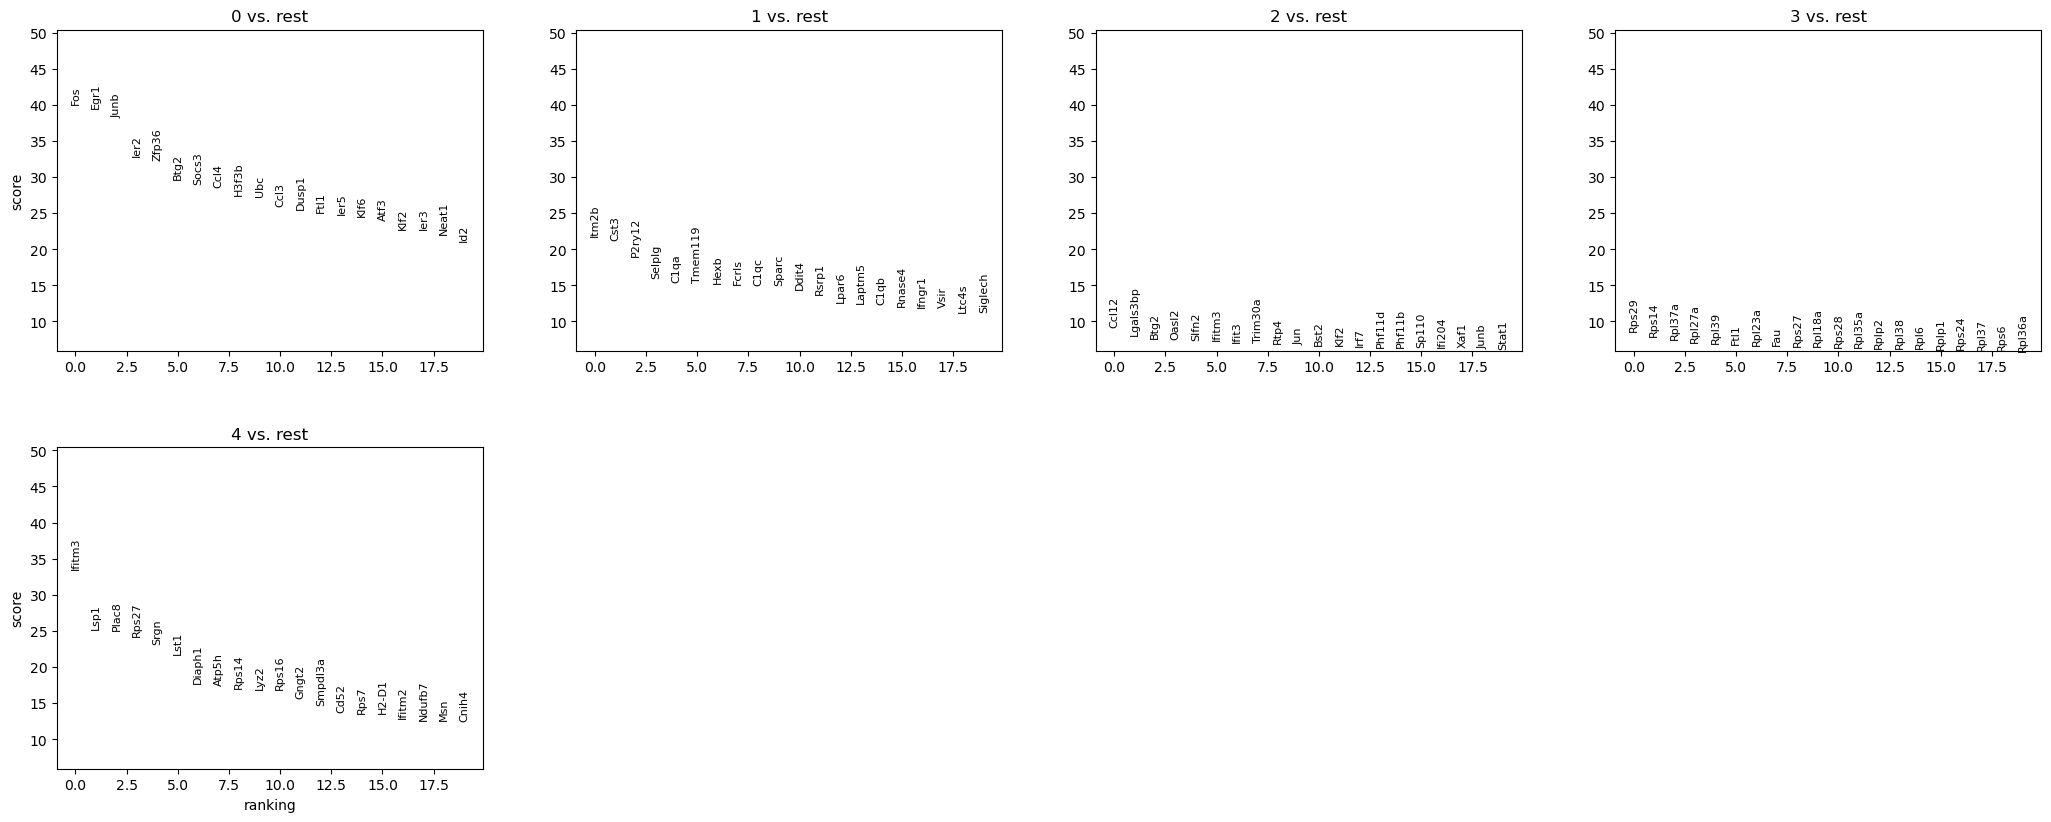

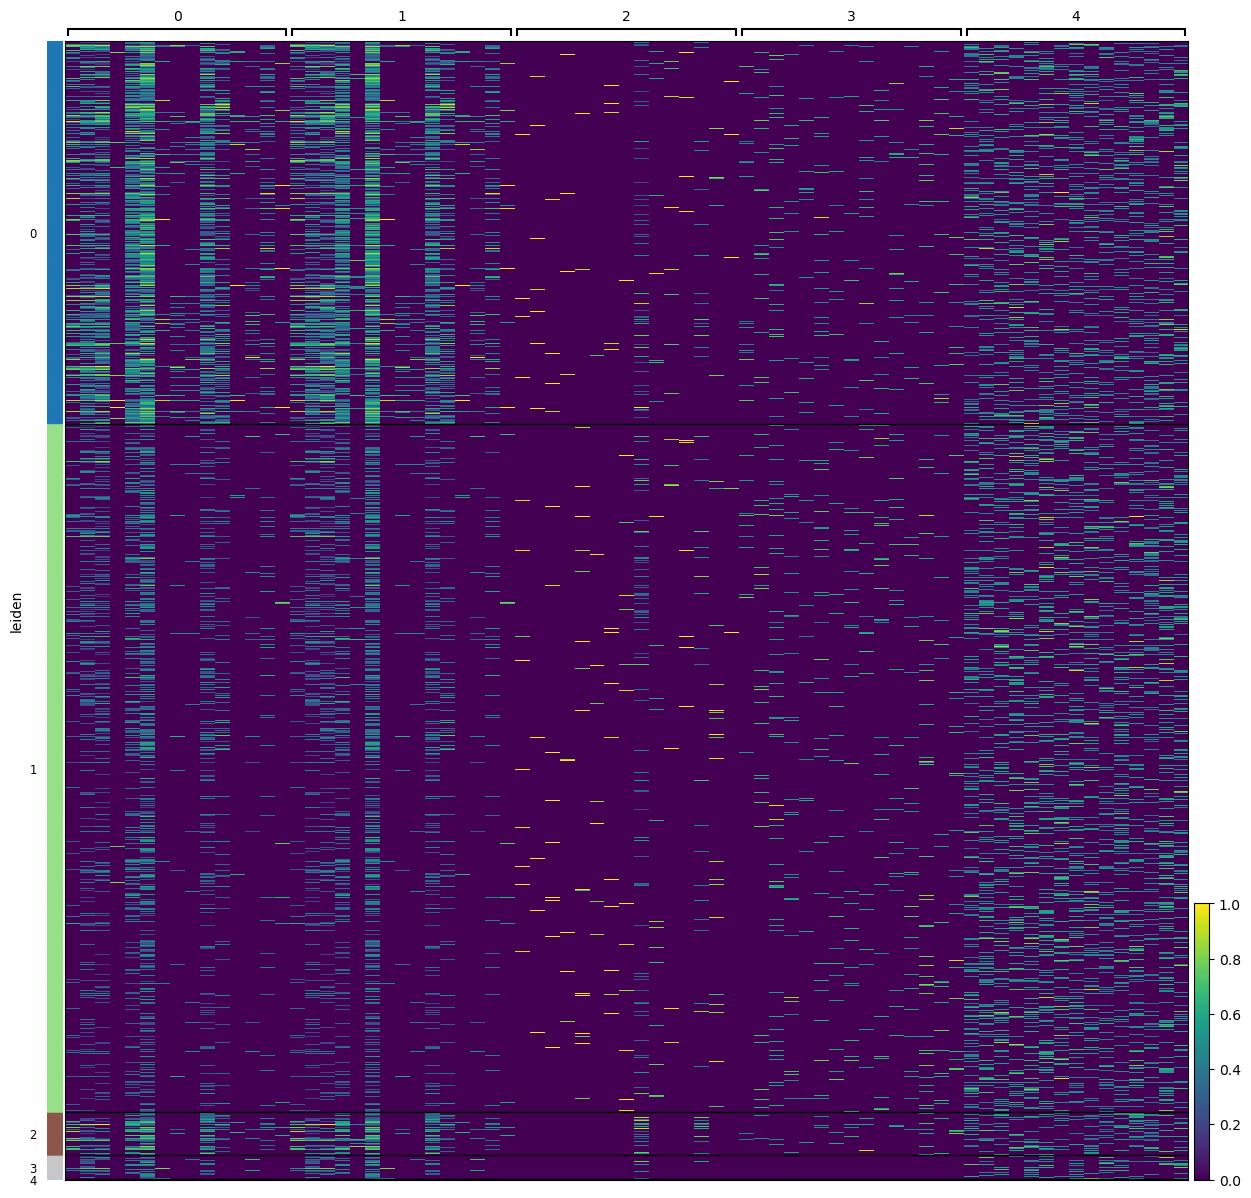

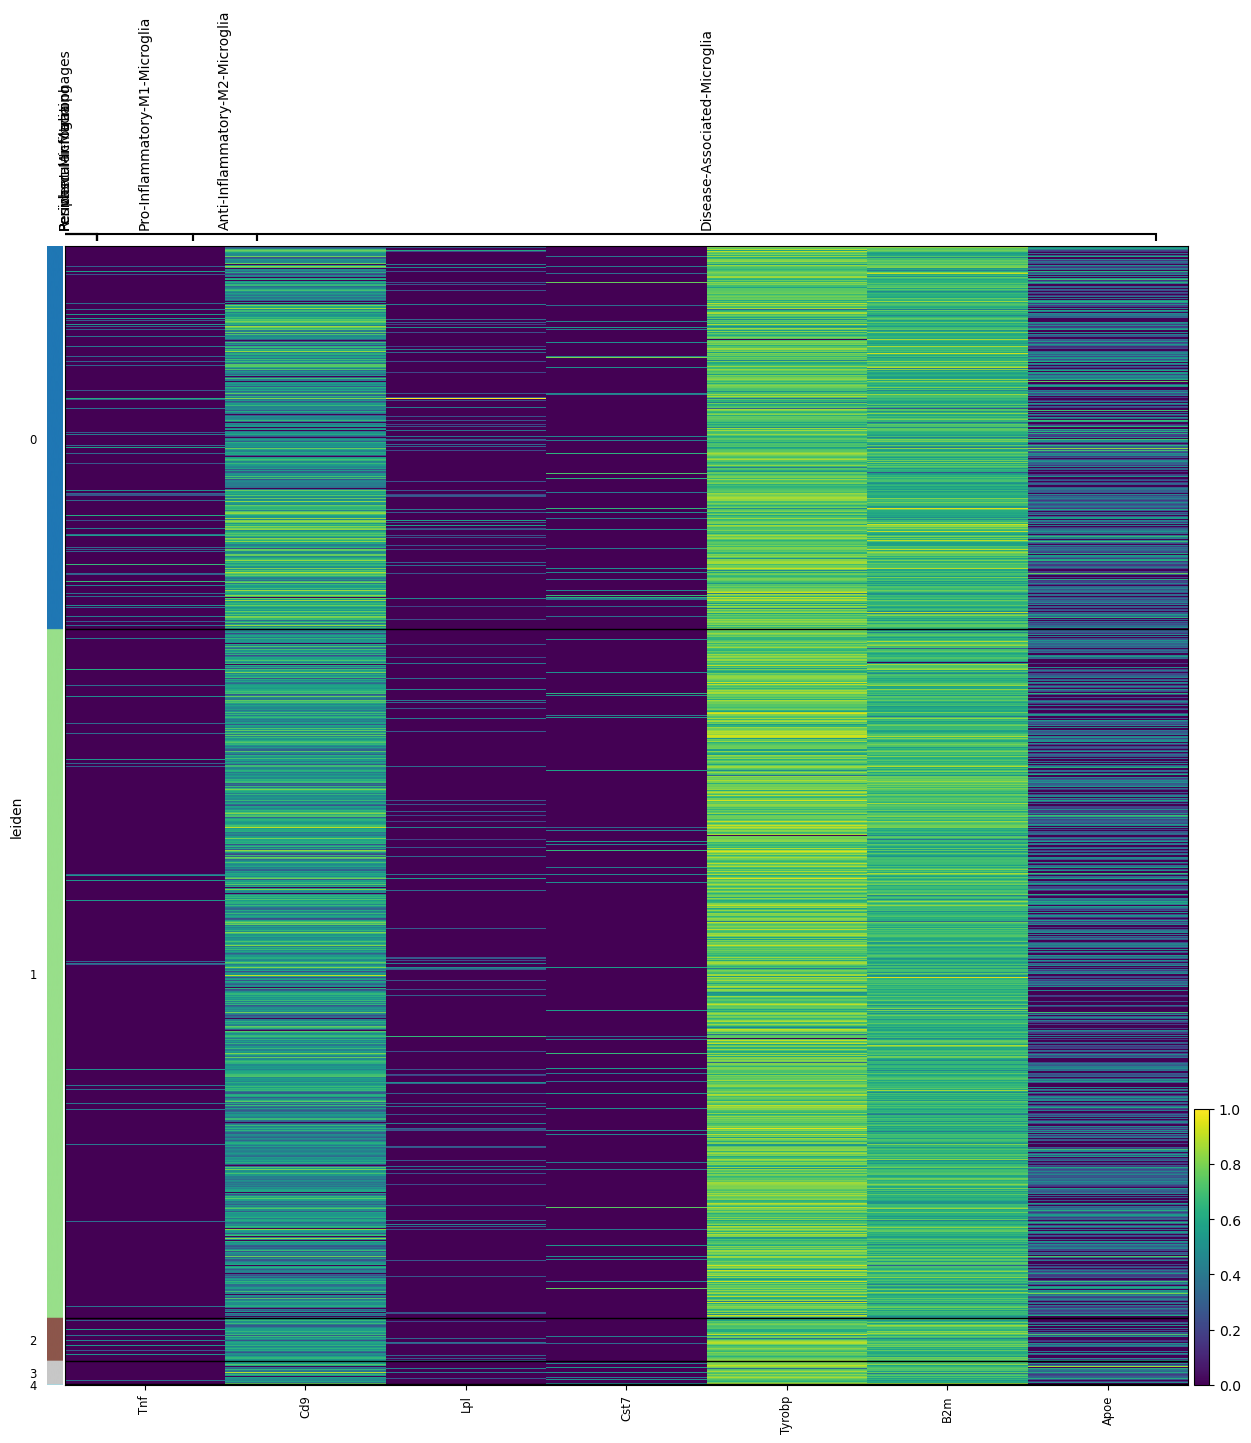

CPU times: user 8 s, sys: 204 ms, total: 8.21 s
Wall time: 1.94 s


scores  logfoldchanges          pvals      pvals_adj
leiden names                                                                 
0      Atf3           24.023277        2.736140  2.245953e-117  1.416916e-114
       Ccl3           25.949648        2.121737  7.300086e-137  6.698824e-134
       Ccl4           28.543293        2.447538  7.311155e-162  9.224850e-159
       Dusp2           6.802550        2.669927   1.228529e-11   5.858204e-10
       Egr1           39.485783        2.359031  2.664106e-290  1.344574e-286
       Fos            40.148006        2.297199  8.974375e-303  9.058734e-299
       Gadd45b        11.597600        3.358575   1.938983e-30   3.058139e-28
       Gas2l3         11.957855        2.628099   2.923569e-32   5.001781e-30
       Gpr162         10.901780        2.208873   3.273847e-27   4.291716e-25
       Ier2           32.870758        2.371983  1.567456e-208  3.164381e-205
       Ier3           22.755436        2.269969  6.861714e-107  3.847897e-104
       Maff            7.953902        2.583077   2.501442e-15   1.694601e-13
       Mt2            10.298725        2.081077   1.621653e-24   2.020860e-22
       Nfkbiz         16.540737        2.088449   3.503501e-59   1.105136e-56
       Nr4a1           5.961379        2.027708   2.759734e-09   9.073863e-08
1      Atf3          -25.338846       -2.865962  6.980267e-131  4.697254e-128
       Ccl3          -27.310637       -2.145365  1.275948e-152  1.170856e-149
       Ccl4          -29.372114       -2.420901  1.676557e-173  2.417595e-170
       Egr1          -40.870583       -2.408892   0.000000e+00   0.000000e+00
       Egr2          -12.742755       -2.249617   1.650080e-36   2.643794e-34
       Fos           -41.363327       -2.303740   0.000000e+00   0.000000e+00
       Gadd45b       -12.061411       -3.545576   7.592015e-33   1.021784e-30
       Gas2l3        -12.176510       -2.635191   1.714628e-33   2.403814e-31
       Gpr162        -10.475588       -2.034147   2.294535e-25   2.438004e-23
       Ier2          -35.173920       -2.473583  8.075674e-240  2.037896e-236
       Ier3          -23.137148       -2.238953  1.085878e-111  6.447563e-109
       Maff           -8.848701       -3.008240   1.360847e-18   1.081605e-16
       Mt2           -12.186569       -2.599389   1.556200e-33   2.212435e-31
       Nfkbiz        -17.190910       -2.131376   4.769116e-64   1.604648e-61
       Nr4a1          -7.885120       -3.009160   4.130798e-15   2.558054e-13
2      A730071L15Rik  -8.893544      -23.747368   7.286779e-19   1.321035e-15
       Cacnb1         -6.906215      -23.053698   5.376059e-12   2.713297e-09
       Fbxo17         -7.560815      -23.349140   4.470450e-14   3.008315e-11
       Fkbp11         -7.820605      -23.402721   5.959300e-15   5.012765e-12
       Fn3krp         -8.843304      -23.880562   1.138797e-18   1.642146e-15
       Gm10093        -9.994471      -24.077728   2.239909e-23   7.536548e-20
       Gm26514        -8.300953      -23.559364   1.210169e-16   1.357272e-13
       Gm2974         -9.273134      -23.897202   2.309587e-20   5.828243e-17
       Ifitm3          7.345066        2.123064   1.871216e-12   9.941080e-10
       Kctd12b       -12.062928      -24.676022   3.311228e-33   3.342353e-29
       Mt3            -8.269465      -23.792803   1.572999e-16   1.587786e-13
       Nupr1l         -7.735792      -23.418736   1.158785e-14   8.837386e-12
       Oasl2           7.488702        2.812325   7.629092e-13   4.529885e-10
       Scfd2         -10.558324      -24.247196   6.997298e-26   3.531536e-22
       Tubgcp6        -8.058550      -23.464106   8.890061e-16   8.157843e-13
3      Cd300lf       -14.987516      -25.368816   4.397308e-50   3.170459e-47
       Cep135        -15.162506      -25.245890   3.350706e-51   2.818502e-48
       Entpd6        -22.337786      -26.384016  3.473534e-107  3.506185e-103
       Fhl3          -15.732759      -25.476524   6.275592e-55   7.038425e-52
       Itpkc         -16.199556      -25.436777

In [26]:
%%time

# Clustering Options
resolution, min_dist = 0.4, 0.3
n_neighbors = 15
cct = "leiden"  # key added/column name
col_celltype, self._info["col_celltype"] = cct, cct  # set default column

# Clustering
self.cluster(col_celltype=cct, resolution=resolution, min_dist=min_dist,
             kws_pca=False, layer="scaled",
             kws_neighbors=dict(n_neighbors=n_neighbors))  # cluster
self.rna.obs = self.rna.obs.assign(**{
       f"{cct}_resolution": resolution}).assign(
              **{f"{cct}_n_neighbors": n_neighbors}).assign(
                     **{f"{cct}_min_dist": min_dist})  # store parameters
_ = self.plot(kind="umap", wspace=0.5, palette="tab20",
              color=[col_batch, "leiden", col_sample])  # plot UMAP
print(self.rna.obs["leiden"].value_counts().to_frame("n_cells"))  # N/cluster
print(self.rna.obs.groupby(col_sample).apply(lambda x: x[
       cct].value_counts(), include_groups=False).unstack(1))  # by group

# DEGs (One Cluster versus All)
self.find_markers(col_celltype=cct)  # DEGs by cluster
markers_df = self.get_markers_df(
    n_genes=15, col_celltype=cct, p_threshold=1e-5, log2fc_threshold=2,
    log2fc_threshold_abs=True).sort_index()
markers_dict = dict(markers_df.groupby(cct).apply(
    lambda x: list(x.reset_index().names)))  # dictionary version of df
# for x in ["obs", "var"]:
for x in ["var"]:
       _ = self.plot(genes=markers_dict, figsize=(15, 15),
                     layer="scaled", standard_scale=x, kind="heat")
if markers_predefined is not None:
    mks_c = {x: markers_predefined[x].intersection(
           self.rna.var_names) for x in markers_predefined}
    if "Inhibitory" in mks_c:
       mks_c["Inhibitory"] = mks_c["Inhibitory"].difference(
              mks_c["Excitatory"])
       mks_c["Excitatory"] = mks_c["Excitatory"].difference(
              mks_c["Inhibitory"])
    _ = self.plot(genes=mks_c, figsize=(15, 15),  # vmax=0.7,
                  layer="log1p", standard_scale="var", kind="heat")
markers_df

# Sub-Clustering

Sub-cluster the biggest <subcluster_biggest> Leiden clusters?

For instance if `subcluster_biggest = 3`, take top three most abundant (highest cell count) clusters and sub-cluster them.

In [ ]:
resolution_sub = None if subcluster_biggest is False else 0.005

if subcluster_biggest is not False:

    # Sub-Clustering
    col_celltype = "leiden_subcluster"
    biggest_clusters = self.rna.obs["leiden"].value_counts().index.values[
        :min(len(self.rna.obs["leiden"].unique()), subcluster_biggest)]
    self.rna.obs.loc[:, col_celltype] = self.rna.obs.leiden.copy()
    for x in biggest_clusters:
        sc.tl.leiden(self.rna, restrict_to=(col_celltype, [x]),
                     key_added=col_celltype, resolution=resolution_sub,
                     seed=0, n_iterations=-1, use_weights=True)
    self.find_markers(col_celltype=col_celltype)  # DEGs by cluster
    self.plot(kind="umap", color=col_celltype)
    print(self.rna.obs[[col_sample, col_celltype]].groupby(
        col_sample).value_counts().unstack(1))
    self.rna.obs.loc[:, f"resolution_{col_celltype}"] = resolution_sub
    self._info["col_celltype"] = col_celltype

    # Marker Plots
    if markers_predefined is not None:
        mks_c = dict(zip(markers_predefined, [markers_predefined[
            x].intersection(self.rna.var_names) for x in markers_predefined]))
        _ = self.plot(genes=mks_c, figsize=(15, 15), vmax=0.7,
                      layer="scaled", standard_scale="obs", kind="heat")
    markers_df = self.get_markers_df(
        n_genes=15, col_celltype=cct,
        p_threshold=1e-10, log2fc_threshold=1.5, log2fc_threshold_abs=False)
    markers_dict = dict(markers_df.groupby(cct).apply(
        lambda x: list(x.reset_index().names)))  # dictionary version of df
    _ = self.plot(genes=markers_dict, figsize=(15, 15),
                  layer="scaled", standard_scale="obs", kind="heat")
    print(markers_df)

# Annotate

Annotate cell types with various methods

## Annotate by Marker Gene Overlap

File from https://github.com/nasa/GeneLab_Data_Processing/blob/master/scRNAseq/10X_Chromium_3prime_Data/GeneLab_CellType_GeneMarkers/GL-DPPD-7111_GeneMarker_Files/GL-DPPD-7111_Mmus_Brain_CellType_GeneMarkers.csv

**Example of the Expected Marker Definition Format**
```
markers_predefined = {
    "CD4 T cells": {"IL7R"},
    "CD14+ Monocytes": {"CD14", "LYZ"},
    "B cells": {"MS4A1"},
    "CD8 T cells": {"CD8A"},
    "NK cells": {"GNLY", "NKG7"},
    "FCGR3A+ Monocytes": {"FCGR3A", "MS4A7"},
    "Dendritic Cells": {"FCER1A", "CST3"},
    "Megakaryocytes": {"PPBP"},
}
```

In [ ]:
# Plot
_ = self.plot(genes=mks_c, figsize=(15, 15),
              layer="scaled", standard_scale="var", kind="matrix")

# Annotate
marker_matches = self.annotate(
    mks_collapsed,
    # celltypes_superhierarchical=celltypes_superhierarchical,
    col_celltype=col_celltype, col_celltype_new="annotation_by_overlap",
    top_n_markers=50,  # can only have this one or `adj_pval_threshold`
    # adj_pval_threshold=1e-10,
    # method="overlap_count",
    method="overlap_coef",
    # method="jaccard",
    overwrite=True)

# Plot Predefined Marker Expression
# cct = col_celltype
# # cct = "annotation_by_markers_individual"
# mks_col = dict(zip(self.rna.obs[cct].cat.categories, [list(
#     mks_collapsed[x].intersection(self.rna.var_names)
#     ) for x in self.rna.obs[cct].cat.categories]))
# _ = self.plot(genes=mks_col, figsize=(15, 15), col_celltype=cct,
#               layer="scaled", standard_scale="obs", kind="heat")

# Rename Any Labels If Desired
if rename_marker_based_annotation is not None:
    self.rna.obs.loc[:, "annotation_by_overlap"] = self.rna.obs[
        "annotation_by_overlap"].replace(rename_marker_based_annotation)

# Print & Plot Results
self.plot(kind="umap", color="annotation_by_overlap", wspace=0.4)
print(round(self.rna.obs["annotation_by_overlap"].value_counts(
    normalize=True) * 100, 2))
round(self.rna.obs[[col_celltype, "annotation_by_overlap"]
                   ].value_counts(normalize=True)* 100, 2).sort_values()

## Annotate with ToppGene

In [ ]:
# Options
min_genes = 1  # minimum markers that have to overlap between Leiden & atlas
remove_strings = ["----L1-6", # "---[|]M.*",
                  "facs-", "-nan-",
                  # "-i_Gaba_3-.*",
                  "Brain_organoid-organoid_Kanton_Nature-Organoid-..-",
                  # "Non-neuronal-Macroglial-((^|)(Oligo|Astro))+-",
                  # "-Glut_E.*IL7R",
                  "cells hierarchy compared to all cells using T-S.*",
                  ".*-organoid_Tanaka_cellReport-.+-",
                  "...BrainAtlas -.*", "-eN2.*", "...Sample groups.*",
                  "...Sample Type, Dataset.*",
                  "-Neuronal",
                  " // Primary Cells by Cluster",
                  ".World...Primary Cells by Cluster",
                  "Brain_organoid-organoid_Velasco_nature-6_",
                  "Fetal_brain-fetalBrain_Zhong_nature-....-",
                  "Somatosensory_Cortex_....-Neuronal-",
                  "Non-neuronal-Non-dividing-",
                  "...Sample groups..6 Anatomical region groups., with 5.*",
                  "Brain_organoid-organoid_Paulsen_bioRxiv-",
                  "-Glut_E_(THEMIS)", "[(]THEMIS[)]",  # "[|].*",
                  "- method, tissue, subtissue, age, lineage.*"]
drop_name_patterns = ["striatum", "globus", "Entopeduncular",
                      "Substantia_nigra-", "Thalamus-"]
toppgene_rename_by_pattern = dict(
    Inhibitory=["Inh(_|ib)", "GABA"], Excitatory=["Excit", "Glut"],
    # Inhibitory=["Inh(_|ib)"], Excitatory=["Excit"],
    # # Gabaergic=["GABA"], Glutamatergic=["Glut"],
    Astrocyte=["Astrocyte","Astroglia", "Macroglial-Astro"],
    Microglial=["Microglia", "Micro"],
    Endothelial=["Endothelial"],
    Oligodendrocyte=[r"^(?=.*oligo)(?!.*poly)(?!.*opc).*"],
    OPC=["Polydendrocyte", "OPC"])
drop_regions = [
    "Mid-temporal_gyrus_(MTG)", "primary_auditory_cortex_(A1C)",
    "Somatosensory_Cortex_(S1)", "Anterior_Cingulate_gyrus_(CgG)",
    "Primary_Motor_Cortex_(M1)",
    "Mid-temporal_gyrus_(MTG)|Mid-temporal_gyrus_(MTG)",
    "primary_auditory_cortex_(A1C)|primary_auditory_cortex_(A1C)",
    "Somatosensory_Cortex_(S1)|Somatosensory_Cortex_(S1)",
    "Anterior_Cingulate_gyrus_(CgG)|Anterior_Cingulate_gyrus_(CgG)",
    "Primary_Motor_Cortex_(M1)|Primary_Motor_Cortex_(M1)",
    r"Neuronal|World / ",
    "Primary_Visual_cortex_(V1C)|Primary_Visual_cortex_(V1C)",
    "mon",
    "BMP_responsible_cell|6m", "bearing_cell|6m", "bearing_cell|GW16", "11",
    "Non-neuronal-Non-dividing",
    "Frontal_cortex|Frontal_cortex",
    "Primary_Visual_cortex_(V1C)", "Substantia_nigra",
    "Thalamus", "Hippocampus", "Frontal_cortex"
]  # remove if name is just a region or top-level hierarchical/undesired type
drop_regions = drop_regions + [f"{i}-Non-neuronal" for i in drop_regions]

# Query ToppGene
results_toppgene = scflow.pp.annotate_by_toppgene(
    markers_dict, remove_strings=remove_strings,
    species=species, min_genes=min_genes, source_patterns=source_patterns)

# Remove or Alter Certain Name Patterns
drop_names = results_toppgene.Name.apply(lambda x: not any((
    i.lower() in x.lower() for i in drop_name_patterns)))
results_toppgene = results_toppgene[drop_names]
rn_tg = results_toppgene.Name.apply(lambda x: {x: " | ".join([
    j for j in toppgene_rename_by_pattern if any((re.search(i.lower(
        ), x.lower()) is not None for i in toppgene_rename_by_pattern[
            j]))])}).apply(lambda x: np.nan if x[list(x.keys())[
                0]] == "" else x).dropna().reset_index(drop=True).apply(
                    lambda x: pd.Series(x)).stack().reset_index(
                        0, drop=True)  # renaming guide
results_toppgene = results_toppgene.replace({"Name": dict(rn_tg)})
results_toppgene = results_toppgene[~results_toppgene.Name.isin(drop_regions)]

# Map Labels (Plurality Vote If Sufficient or Top)
top_cs = dict(results_toppgene.groupby(
    "Gene Set").apply(lambda x: x.Name.iloc[:10].value_counts().index.values[
        0] if x.Name.iloc[:10].value_counts(
            normalize=True).iloc[0] >= 0.25 else x.Name[0]))
print("\n".join([f"{k}: {top_cs[k]}" for k in top_cs]), "\n\n")
if "annotation_toppgene" in self.rna.obs:
    self.rna.obs = self.rna.obs.drop("annotation_toppgene", axis=1)
self.rna.obs = self.rna.obs.join(self.rna.obs[col_celltype].replace(
    top_cs).to_frame("annotation_toppgene")).loc[self.rna.obs.index]

# Display Results
if "annotation_by_overlap" in self.rna.obs:
    print(round(self.rna.obs[["annotation_toppgene", "annotation_by_overlap"]
                             ].value_counts(normalize=True).sort_index(
                                 ) * 100, 2), "\n\n")
print(round(self.rna.obs["annotation_toppgene"].value_counts(
    normalize=True) * 100, 2))
results_toppgene.reset_index("ID", drop=True).drop([
    "QValueBonferroni", "QValueFDRBY", "QValueFDRBH",
    "TotalGenes", "Genes"], axis=1)

## Annotate with CellTypist

In [ ]:
%%time

# To Aggregate More Specific Cell Types
celltypist_rename = dict(
    Gabaergic=["GABA"], Glutamatergic=["Glut"],
    Dopaminergic=["Dopa"], Serotonergic=["Sero"],
    Inhibitory=["Inh"], Excitatory=["Exc"],
    Astrocyte=["Astro"],
    Microglia=["Microglia"],
    Pericyte=["peri"],
    Monocyte=["Monocyte"],
    Lymphoid=["Lymphoid"],
    Endothelial=["Endothelial", "Endo"],
    Oligodendrocyte=[r"^(?=.*oligo)(?!.*poly)(?!.*opc).*"],
    OPC=["OPC", "Polydend"])

# Run CellTypist
self.rna.X = self.rna.layers["counts"].copy()
sc.pp.normalize_total(self.rna, target_sum=10000)
sc.pp.log1p(self.rna) # copy=True: do not update adata.X
predictions = self.annotate(
    model_celltypist, col_celltype=col_celltype, layer=None,
    col_celltype_new="", majority_voting=True, min_prop=0.5, use_GPU=True)
if "majority_voting" in self.rna.obs:
    self.rna.obs.loc[:, "majority_voting_short"] = self.rna.obs[
        "majority_voting"].apply(lambda x: " ".join(x.split(
            " ")[1:]) if all((i in [str(i) for i in np.arange(
                0, 10)] for i in x.split(" ")[
                    0])) else x)  # drop pointless #s in front of cell types

# Rename Cell Types
rn_ct = predictions.predicted_labels.groupby("majority_voting").apply(
    lambda x: {x.name: " | ".join([
        j for j in celltypist_rename if any((re.search(
            i.lower(), x.name.lower()) for i in celltypist_rename[
                j]))])}).apply(lambda x: {list(x.keys())[0]: list(x.keys(
                    ))[0]} if x[list(x.keys())[0] ] == "" else x).apply(
                        lambda x: pd.Series(x)).stack().reset_index(
                            0, drop=True)
if "annotation_majority_voting" in self.rna.obs:
    self.rna.obs = self.rna.obs.drop("annotation_majority_voting", axis=1)
self.rna.obs = self.rna.obs.join(self.rna.obs.replace({
    "majority_voting": dict(rn_ct)})["majority_voting"].to_frame(
        "annotation_majority_voting"))
self.rna.X = self.rna.layers["scaled"].copy()

## Annotate with Map My Cells

- Make sure to run the following bash commonds after activating the conda environment used for this notebook.

- Pull [`cell_type_mapper`](https://github.com/AllenInstitute/cell_type_mapper) from GitHub (clone into your home directory): `cd && git clone git@github.com:AllenInstitute/cell_type_mapper.git`

- Navigate to that directory and run `pip install .`

- Navigate to the folder containing this notebook.

- Install ABC Atlas (while in same directory as this notebook): `pip install -U git+https://github.com/alleninstitute/abc_atlas_access >& scratch/junk.txt`

- Pull lookup files (while in same directory as this notebook):
```
cd resources
wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WMB-10X/20240831/mouse_markers_230821.json
wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WMB-10X/20240831/precomputed_stats_ABC_revision_230821.h5
```

---

Note: To use GPU + Torch, you may need to alter the file "cell_type_mapper/src/cell_type_mapper/cell_by_gene/cell_by_gene.py" line `np.where(np.logical_not(np.isfinite(data)))[0]` to read instead

```
try:
    nan_rows = np.where(
        np.logical_not(np.isfinite(data.cpu().numpy())))[0]
except Exception:
    nan_rows = np.where(np.logical_not(np.isfinite(data)))[0]
```

You may have to run the following code in this notebook:

```
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
```

and

    `_correlation_dot_gpu()` in distance_utils.py change
    `correlation = torch.matmul(arr0, arr1)` to

```
try:
    correlation = torch.matmul(arr0, arr1)
except RuntimeError as err:
    if "CUBLAS_STATUS_NOT_INITIALIZED" in str(err):
        arr0_cpu = arr0.cpu()
        arr1_cpu = arr1.cpu()
        correlation = torch.matmul(arr0_cpu, arr1_cpu).to(arr0.device)
    else:
        raise
```

to manage processes/memory.

In [ ]:
%%time

# Write File to Use as Input for Map My Cells
if overwrite is True or not os.path.exists(file_new):
    os.makedirs("data", exist_ok=True)
    self.rna.X = self.rna.layers["counts"]
    self.rna.write_h5ad(file_new)
else:
    raise ValueError("Must be able to overwrite to run Map My Cells.")

# Run Map My Cells
self.rna = scflow.pp.run_mapbraincells(
    file_new, map_my_cells_source=map_my_cells_source,
    dir_scratch="scratch", dir_resources="resources",
    validate_output_file="scratch/tmp.h5ad",  # map_to_ensembl=True,
    map_my_cells_region_keys=map_my_cells_region_keys,
    map_my_cells_cell_keys=map_my_cells_cell_keys, verbose_stdout=True,
    n_processors=4, chunk_size=5000, max_gb=5)

View Results
_ = self.plot(kind="umap", color=["cellmap_class_name"])
if "annotation_toppgene" in self.rna.obs:
    print(self.rna.obs[["cellmap_class_name", "annotation_toppgene"]
                       ].value_counts().sort_index())
self.rna.obs[[i for i in self.rna.obs if "cellmap" in i and "ori" not in i]]

## Compare Annotations

In [ ]:
cols = ["annotation_by_overlap", "annotation_scanvi",
        "annotation_toppgene", "annotation_majority_voting"]
# cols += [i for i in [
#     "cellmap_class_name", "cellmap_subclass_name"] if i in self.rna.obs]
cols = [i for i in cols if i in self.rna.obs]

# Plot UMAPs
self.plot(kind="umap", color=cols, wspace=0.3)

# Compare
# self.rna.obs[cols].value_counts().reset_index().groupby(cols[0]).apply(
#         lambda x: x.sort_values("count", ascending=False).reset_index(
#                 drop=True), include_groups=False).reset_index(
#                         -1, drop=True).set_index(cols[1:], append=True)
self.rna.obs[cols].groupby(cols[0]).apply(
        lambda x: round(100 * x.value_counts(normalize=True), 1).sort_index(
                ).sort_values(ascending=False), include_groups=False)

# OSD-613-Specific

Clean variable names & keys

In [ ]:
self.rna.obs.loc[:, "Age_Start"] = self.rna.obs["Factor Value[Age]"].astype(
    str) + " Weeks"
self.rna.obs.loc[:, "Age_End"] = self.rna.obs[
    "Characteristics[Age at Euthanasia]"].astype(str) + " Weeks"
self.rna.obs.loc[:, "Condition"] = self.rna.obs["Factor Value[Spaceflight]"]
if "cellmap_class_name" in self.rna.obs:  # cell name w/o region cues
    self.rna.obs.loc[:, "cellmap_class_name_collapsed"] = self.rna.obs[
        "cellmap_class_name"].apply(lambda x: x + "***" + str(
            "Glutamatergic-" if ("glut" in x.lower()) else "") + str(
                "GABAergic-" if "gaba" in x.lower() else "") + str(
                    "Oligodendrocyte-" if "oligo" in x.lower() else "") + str(
                        "Cholinergic-" if "chol" in x.lower() else ""))
    self.rna.obs.loc[:, "cellmap_class_name_collapsed"] = self.rna.obs[
        "cellmap_class_name_collapsed"].apply(
            lambda x: x.split("***")[0 if x.split("***")[1] == "" else 1])
    self.rna.obs.loc[:, "cellmap_class_name_collapsed"] = self.rna.obs[
        "cellmap_class_name_collapsed"].apply(
            lambda x: x[:-1] if x[-1] == "-" else x)

# Final Write

In [ ]:
# Descriptives
if all((i in self.rna.obs for i in [
        "Factor Value[Age]", "Characteristics[Age at Euthanasia]"])):
    print(self.rna.obs[["Factor Value[Age]",
                        "Characteristics[Age at Euthanasia]"]].value_counts())

# Write h5ad
# self.rna.X = self.rna.layers["counts"].copy()
if overwrite is True or not os.path.exists(file_new):
    print("\n\n", f"Writing file to {file_new}...")
    self.rna.write_h5ad(file_new)

## Write Version Compatible with Older Packages
# adata = self.rna.copy()
# adata.uns = {}
# # adata.write_h5ad(os.path.splitext(file_new)[0] + "_compatible.h5ad")

# Send Email with Output When Done
if email is not None and html_out is not None:
    os.system(f"jupyter nbconvert --to html {cur_file}")
    os.system(f"echo 'yay' | mutt -s 'JOB DONE' -a {html_out} -- {email}")

# SCRATCH (IGNORE)

In [ ]:
# mks_c = dict(zip(markers_predefined, [markers_predefined[x].intersection(
#         self.rna.var_names) for x in markers_predefined]))
# mks_c["Inhibitory"] = mks_c["Inhibitory"].difference(mks_c["Excitatory"])
# mks_c["Excitatory"] = mks_c["Excitatory"].difference(mks_c["Inhibitory"])
# endo = list(mks_c["Endothelial"].difference(set(functools.reduce(
#     lambda i, j: i + j, [list(
#         mks_c[i]) for i in mks_c if i != "Endothelial"]))))
# _ = self.plot(genes=endo, figsize=(15, 15),
#               col_celltype="annotation_scanvi",
#               # col_celltype="annotation_by_overlap",
#               layer="scaled", standard_scale="var", kind="matrix")